In [108]:
d.beluga <- read.table("http://stat.ethz.ch/Teaching/Datasets/WBL/beluga.dat",
header=T)
d.beluga <- ts(d.beluga)

In [109]:
d.beluga

,PERIOD,BOUTS,NURSING,LOCKONS,DAYNIGHT
1,1,0.000000,0.000000,0.000000,0
2,2,0.000000,0.000000,0.000000,1
3,3,0.000000,0.000000,0.000000,1
4,4,0.000000,0.000000,0.000000,0
5,5,0.000000,0.000000,0.000000,0
6,6,2.000000,5.099020,2.236068,1
7,7,3.162278,6.480741,3.316625,1
8,8,3.000000,11.958261,4.123106,0
9,9,3.605551,15.620499,5.744563,0
10,10,3.000000,11.704700,5.000000,1


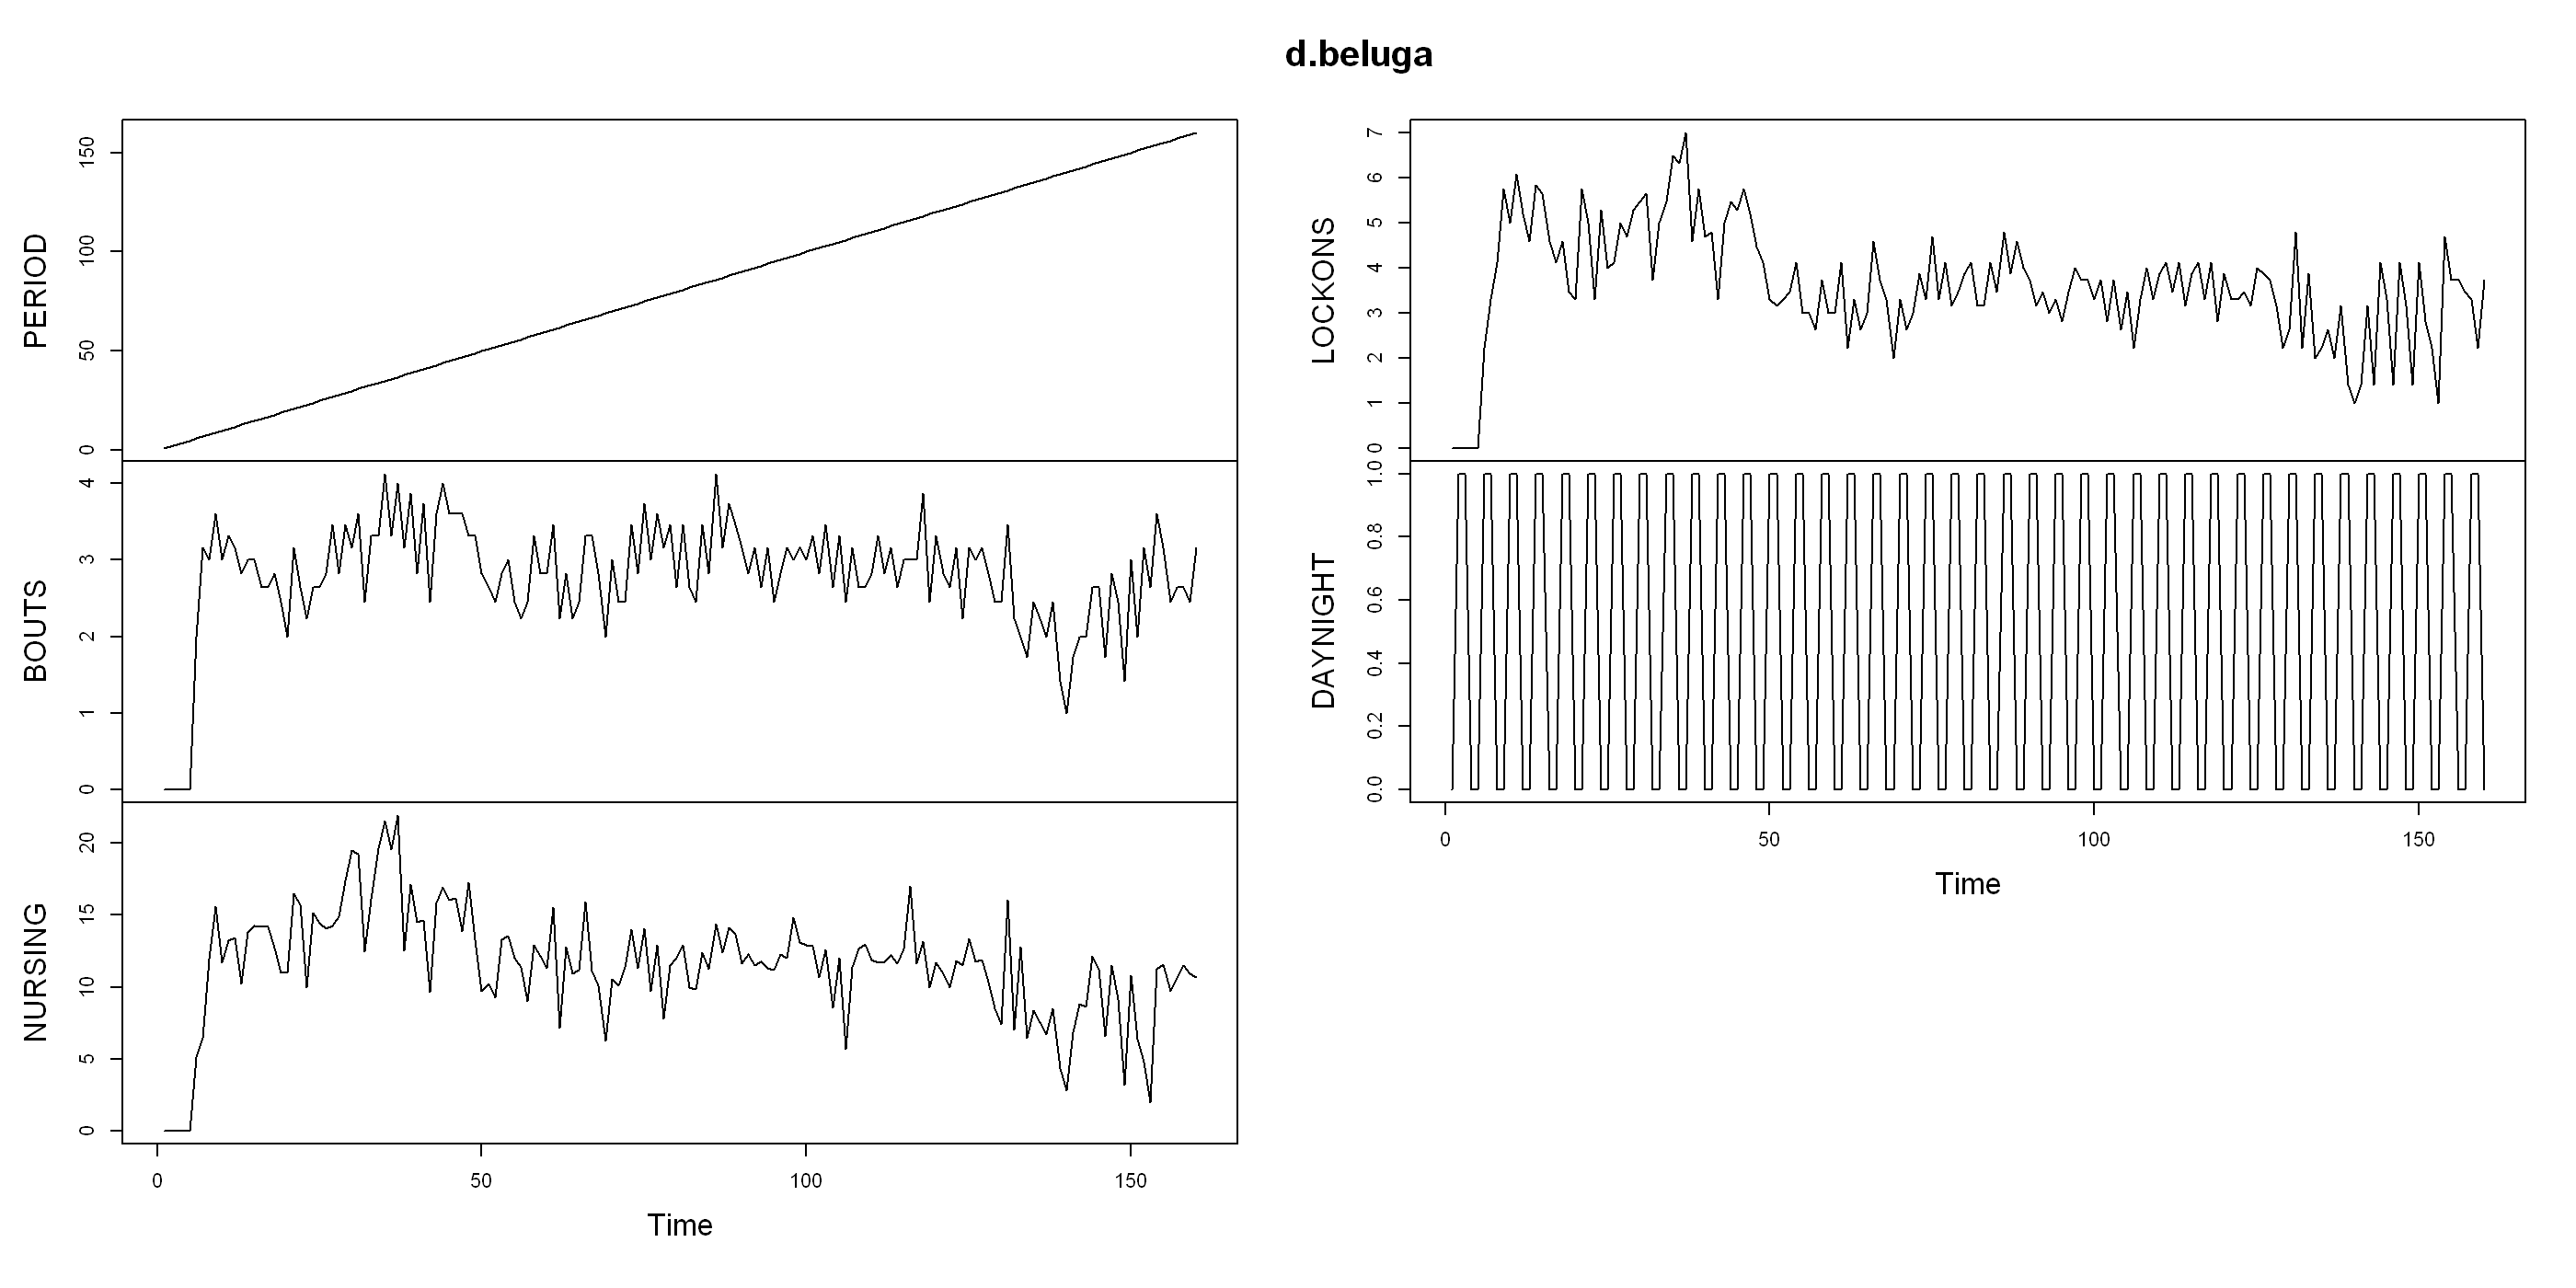

In [110]:
plot(d.beluga)

In [111]:
# PERIOD	BOUTS	NURSING	LOCKONS	DAYNIGHT

In [112]:
period <- d.beluga[,1]
bouts <- d.beluga[,2]
nursing <- d.beluga[,3]

lockons <- d.beluga[,4]
daynight <- d.beluga[,5]



In [113]:
model <- lm(nursing~period+bouts+lockons+daynight)

In [114]:
model


Call:
lm(formula = nursing ~ period + bouts + lockons + daynight)

Coefficients:
(Intercept)       period        bouts      lockons     daynight  
  0.5602842    0.0001998    0.8784967    2.3903512   -0.3416237  


In [115]:
summary(model)


Call:
lm(formula = nursing ~ period + bouts + lockons + daynight)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.4457 -0.9018 -0.0850  1.0952  3.9548 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.5602842  0.5502170   1.018  0.31012    
period       0.0001998  0.0031937   0.063  0.95020    
bouts        0.8784967  0.3336237   2.633  0.00932 ** 
lockons      2.3903512  0.2035042  11.746  < 2e-16 ***
daynight    -0.3416237  0.2510156  -1.361  0.17550    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 1.582 on 155 degrees of freedom
Multiple R-squared:  0.842,	Adjusted R-squared:  0.8379 
F-statistic: 206.5 on 4 and 155 DF,  p-value: < 2.2e-16


In [116]:
options(repr.plot.width = 10, repr.plot.height = 7, repr.plot.res = 200)

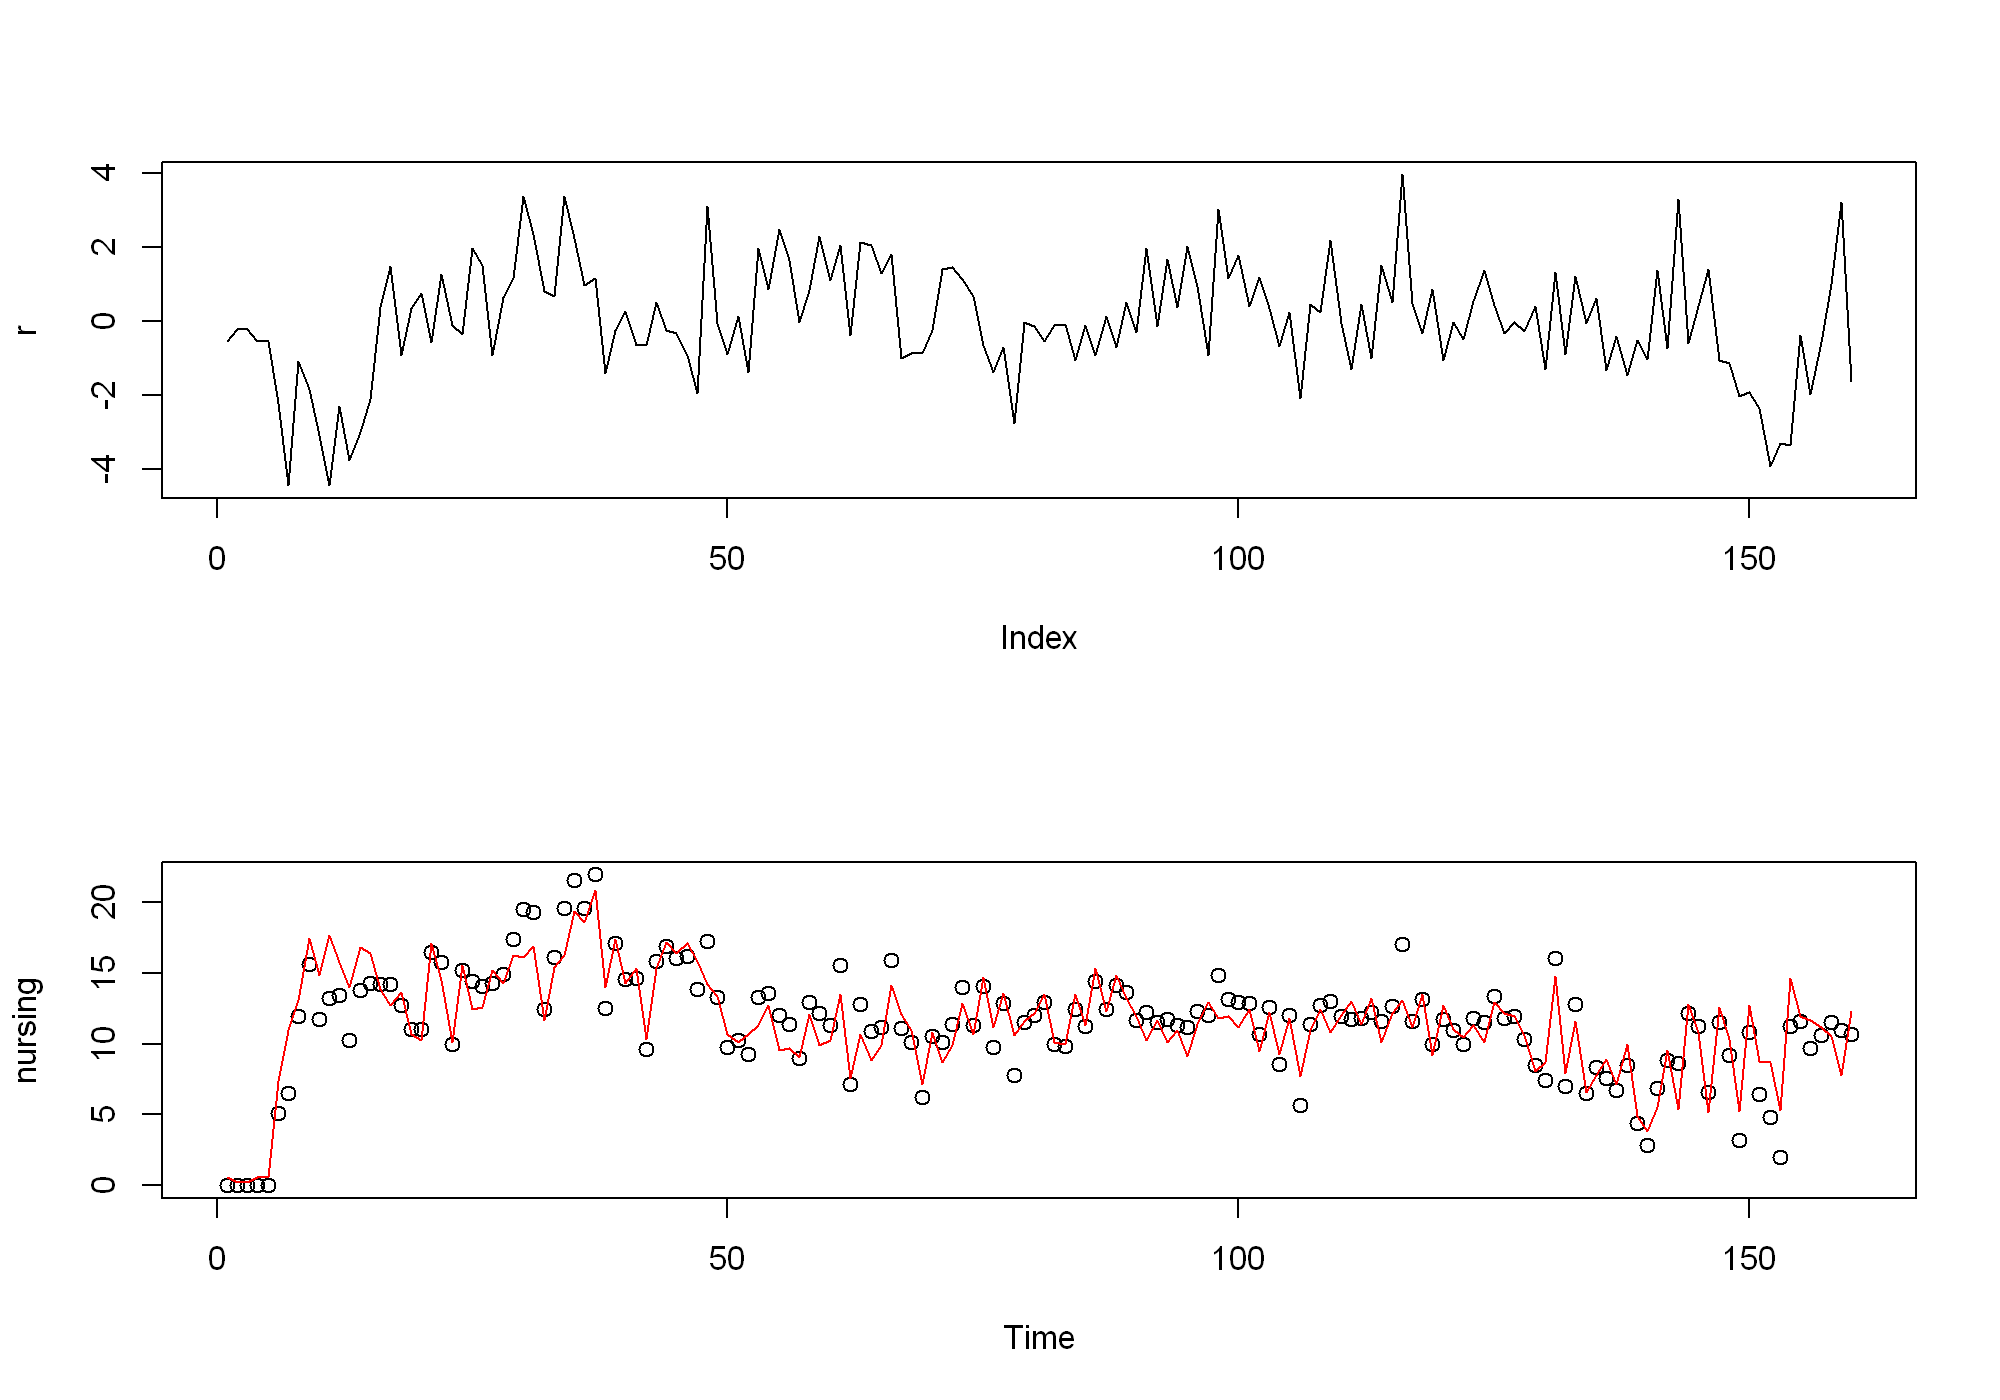

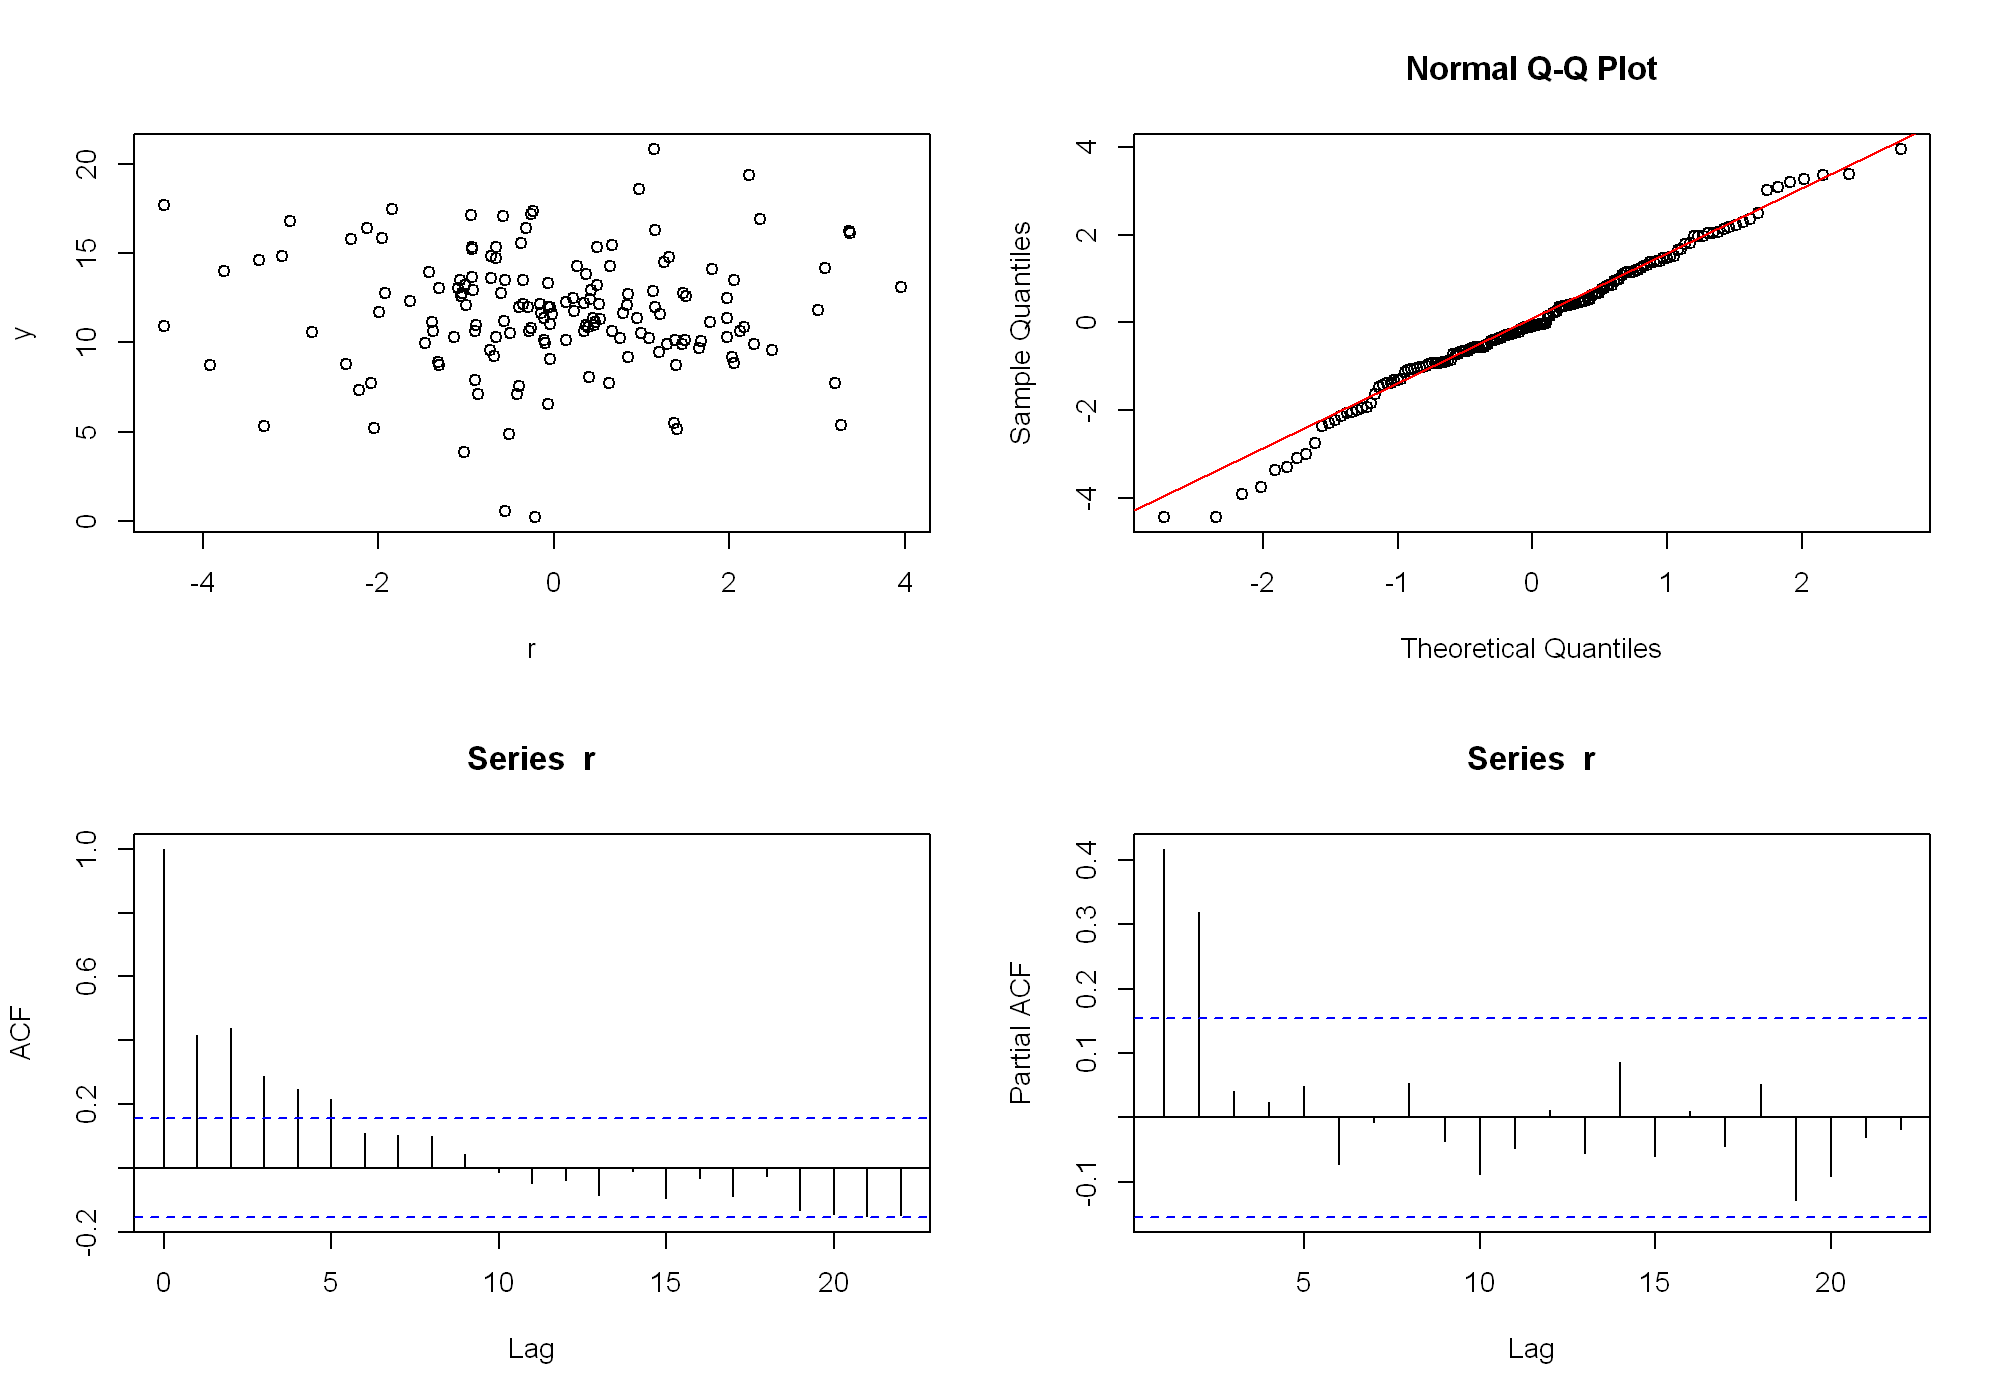

In [117]:
r <- na.omit(model$residuals)
y <- as.numeric(model$fitted.values)
par(mfrow = c(2,1))
plot(r,type="l")
plot(nursing,type="p")
lines(y,col="red")
par(mfrow = c(2,2))

plot(r,y,type="p")
qqnorm(r)
qqline(r,col="red")
acf(r)
pacf(r)


In [118]:
library(forecast)

In [119]:
auto.arima(r,max.p = 5,max.q = 0)

Series: r 
ARIMA(2,0,0) with zero mean 

Coefficients:
         ar1     ar2
      0.2756  0.3263
s.e.  0.0755  0.0764

sigma^2 = 1.815:  log likelihood = -273.94
AIC=553.87   AICc=554.02   BIC=563.1

In [120]:
i <- 2:length(nursing)
rho <- 0.276
z <- data.frame(
  nursing = nursing[i] - rho * nursing[i - 1],
  period = period[i] - rho * period[i - 1],
  bouts = bouts[i] - rho * bouts[i - 1],
  lockons = lockons[i] - rho * lockons[i - 1],
  daynight = daynight[i] - rho * daynight[i - 1]
)

model2 <- lm(nursing ~ period + bouts + lockons + daynight, data = z)

In [121]:
model2
summary(model2)


Call:
lm(formula = nursing ~ period + bouts + lockons + daynight, data = z)

Coefficients:
(Intercept)       period        bouts      lockons     daynight  
  0.7368320   -0.0007271    0.8086926    2.3387071   -0.3346431  



Call:
lm(formula = nursing ~ period + bouts + lockons + daynight, data = z)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.8414 -0.9411 -0.0262  0.8914  3.8710 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.7368320  0.4733423   1.557   0.1216    
period      -0.0007271  0.0038955  -0.187   0.8522    
bouts        0.8086926  0.3433874   2.355   0.0198 *  
lockons      2.3387071  0.2069811  11.299   <2e-16 ***
daynight    -0.3346431  0.2230389  -1.500   0.1356    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 1.456 on 154 degrees of freedom
Multiple R-squared:  0.8027,	Adjusted R-squared:  0.7976 
F-statistic: 156.6 on 4 and 154 DF,  p-value: < 2.2e-16


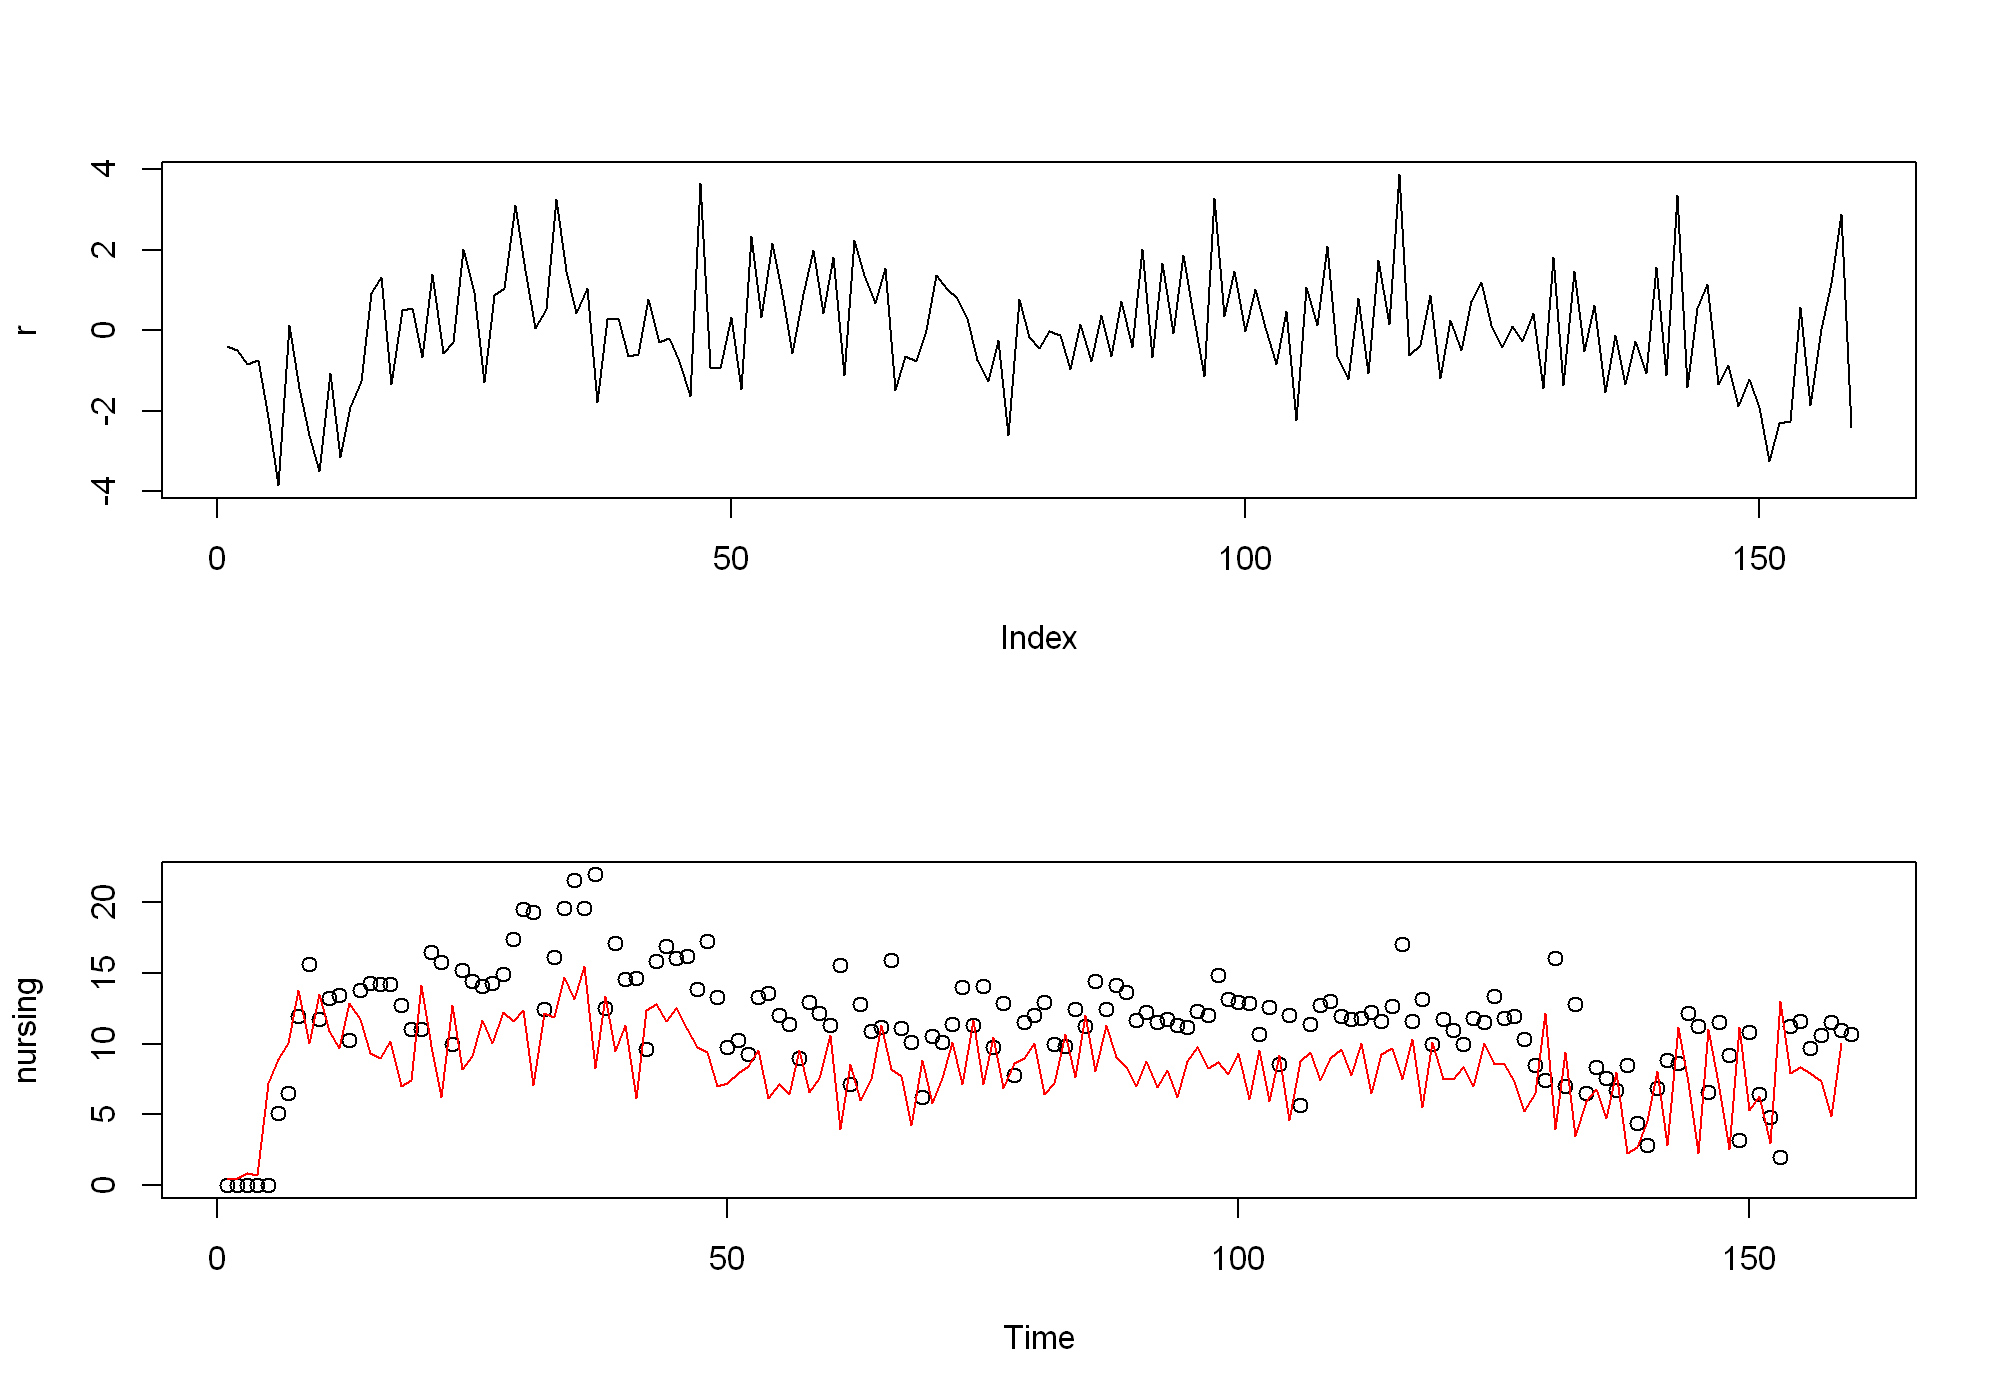

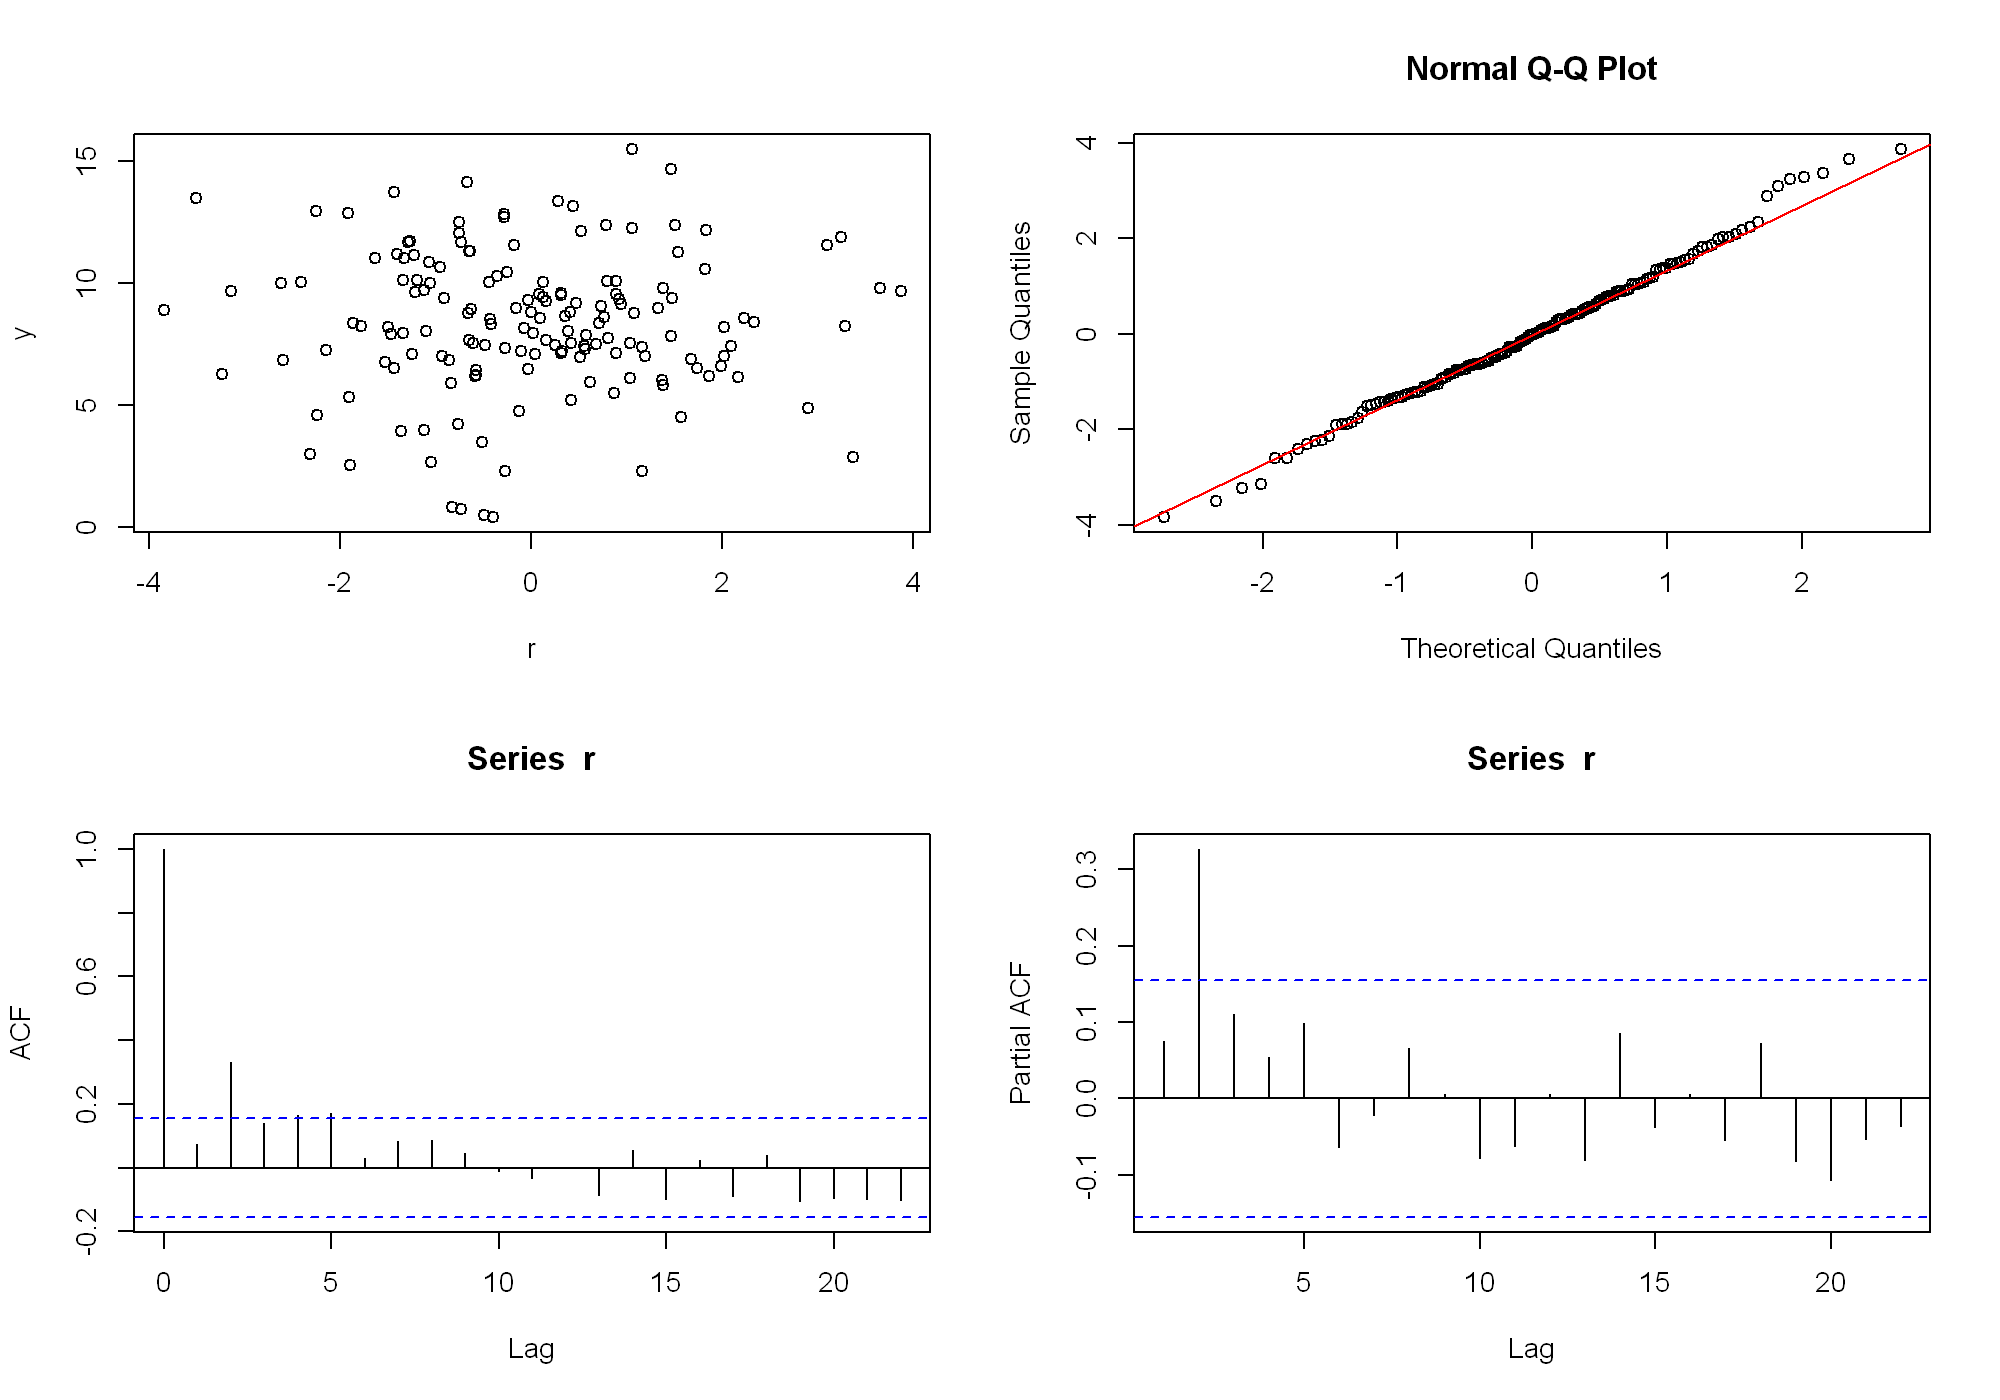

In [122]:
r <- na.omit(model2$residuals)
y <- as.numeric(model2$fitted.values)
par(mfrow = c(2,1))
plot(r,type="l")
plot(nursing,type="p")
lines(y,col="red")
par(mfrow = c(2,2))

plot(r,y,type="p")
qqnorm(r)
qqline(r,col="red")
acf(r)
pacf(r)


In [123]:
library(nlme)

In [124]:
model3 <- gls(
  nursing ~ period + bouts + lockons + daynight,
  correlation = corARMA(p = 2, q = 0, form = ~ period),
  method = "ML"
)

In [125]:
model3

Generalized least squares fit by maximum likelihood
  Model: nursing ~ period + bouts + lockons + daynight 
  Data: NULL 
  Log-likelihood: -272.198

Coefficients:
 (Intercept)       period        bouts      lockons     daynight 
 1.321887548  0.002498175  0.296168888  2.568191829 -0.308029244 

Correlation Structure: ARMA(2,0)
 Formula: ~period 
 Parameter estimate(s):
     Phi1      Phi2 
0.2739974 0.3653663 
Degrees of freedom: 160 total; 155 residual
Residual standard error: 1.577032 

In [126]:
summary(model3)

Generalized least squares fit by maximum likelihood
  Model: nursing ~ period + bouts + lockons + daynight 
  Data: NULL 
      AIC      BIC   logLik
  560.396 584.9974 -272.198

Correlation Structure: ARMA(2,0)
 Formula: ~period 
 Parameter estimate(s):
     Phi1      Phi2 
0.2739974 0.3653663 

Coefficients:
                 Value Std.Error   t-value p-value
(Intercept)  1.3218875 0.7678369  1.721573  0.0871
period       0.0024982 0.0062754  0.398089  0.6911
bouts        0.2961689 0.3370588  0.878686  0.3809
lockons      2.5681918 0.1964012 13.076253  0.0000
daynight    -0.3080292 0.1549160 -1.988362  0.0485

 Correlation: 
         (Intr) period bouts  lockns
period   -0.607                     
bouts    -0.303 -0.233              
lockons  -0.101  0.251 -0.811       
daynight -0.014  0.024 -0.135  0.067

Standardized residuals:
        Min          Q1         Med          Q3         Max 
-2.80055479 -0.58763711  0.01738819  0.65602026  2.49854049 

Residual standard error: 1.577032

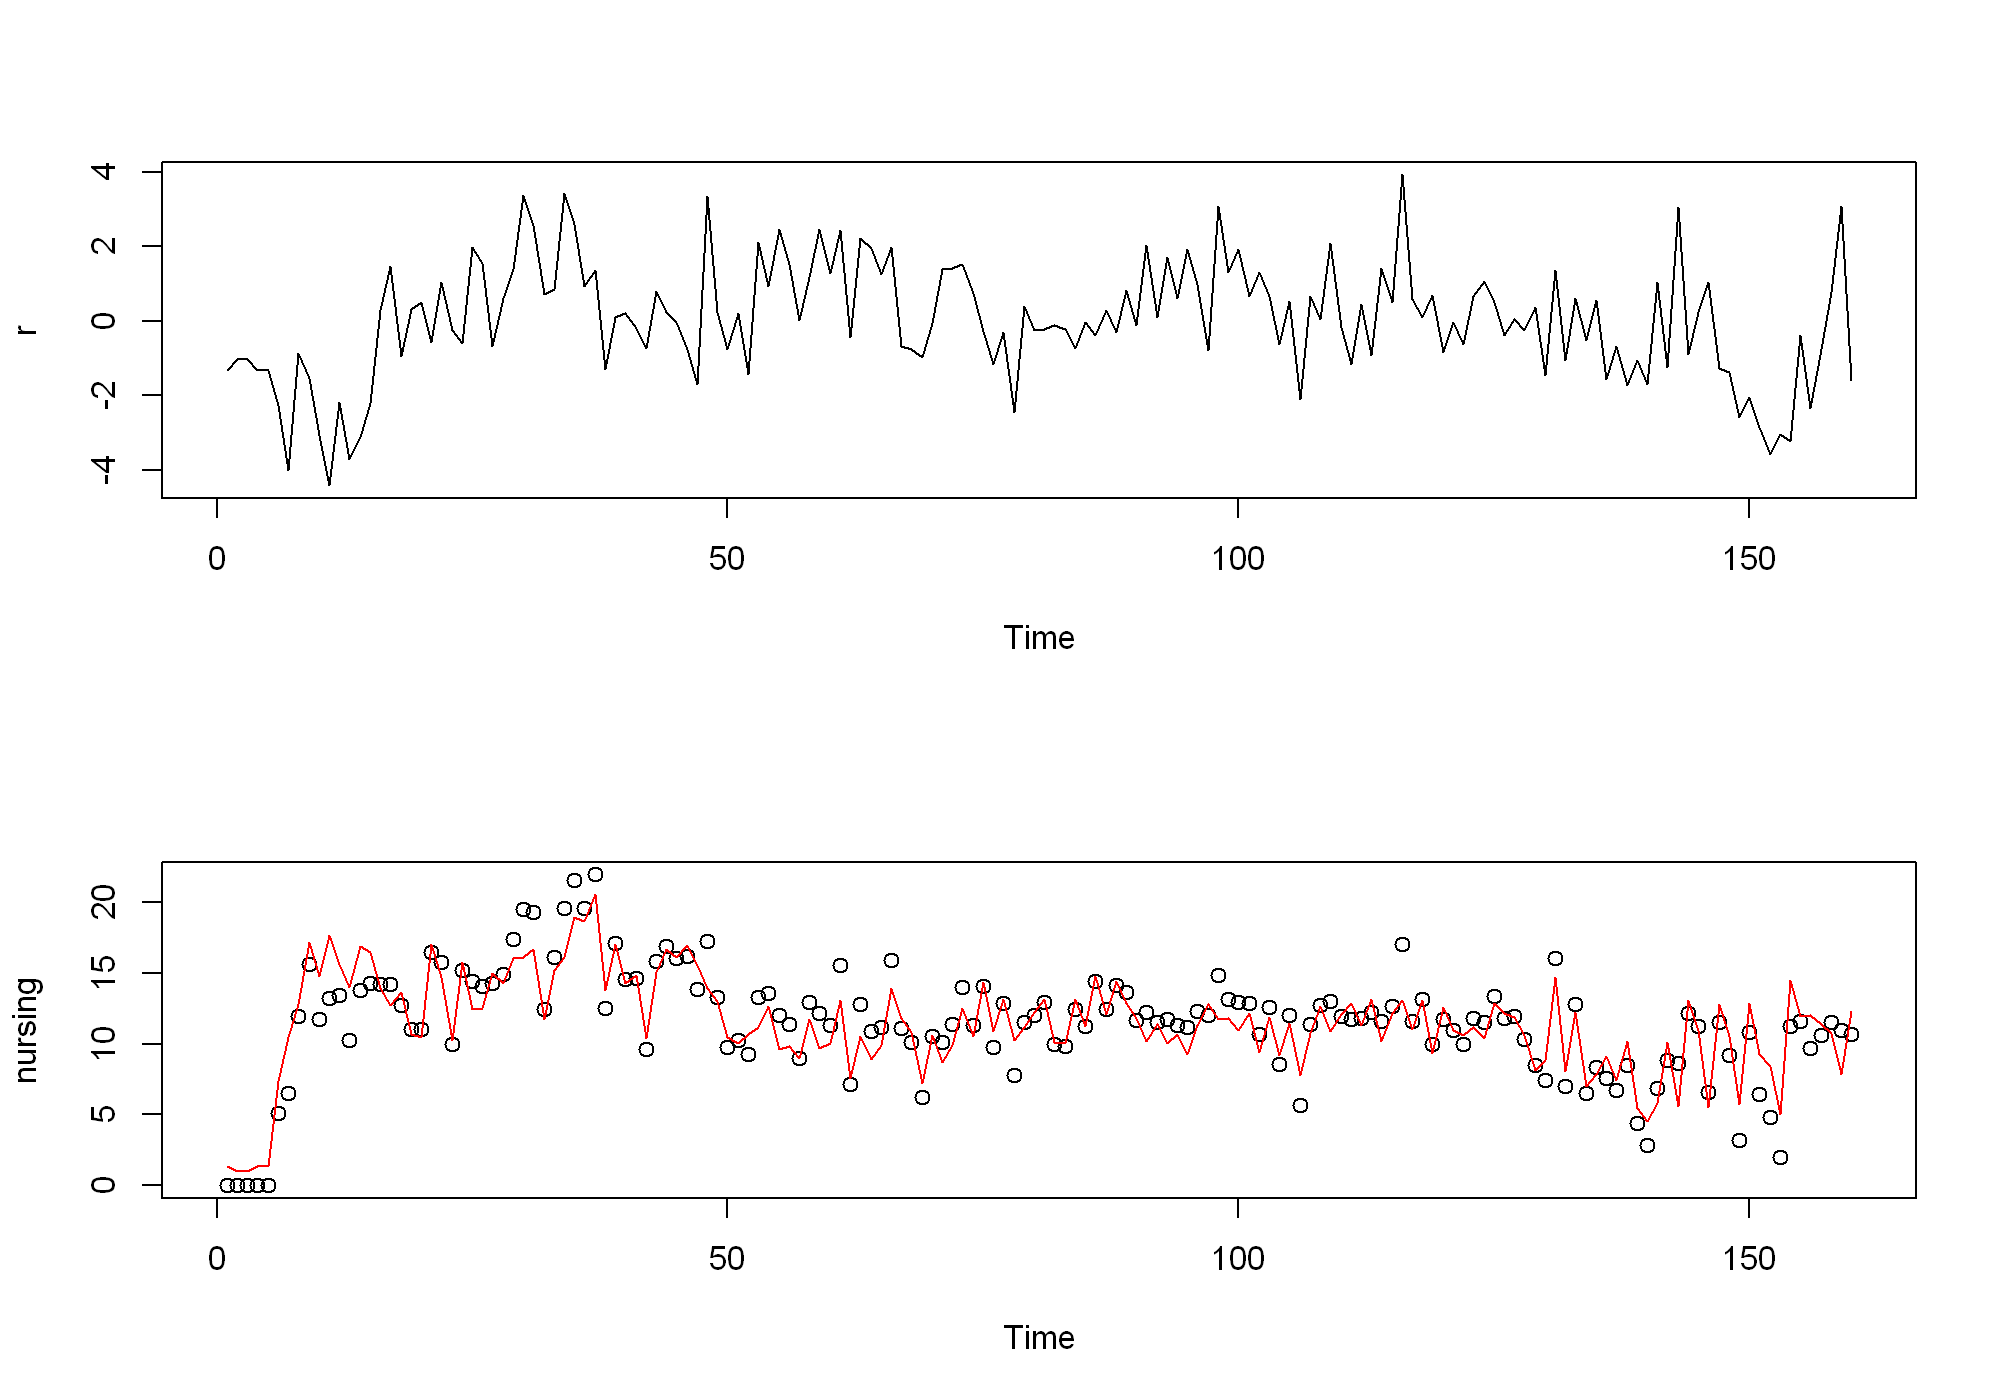

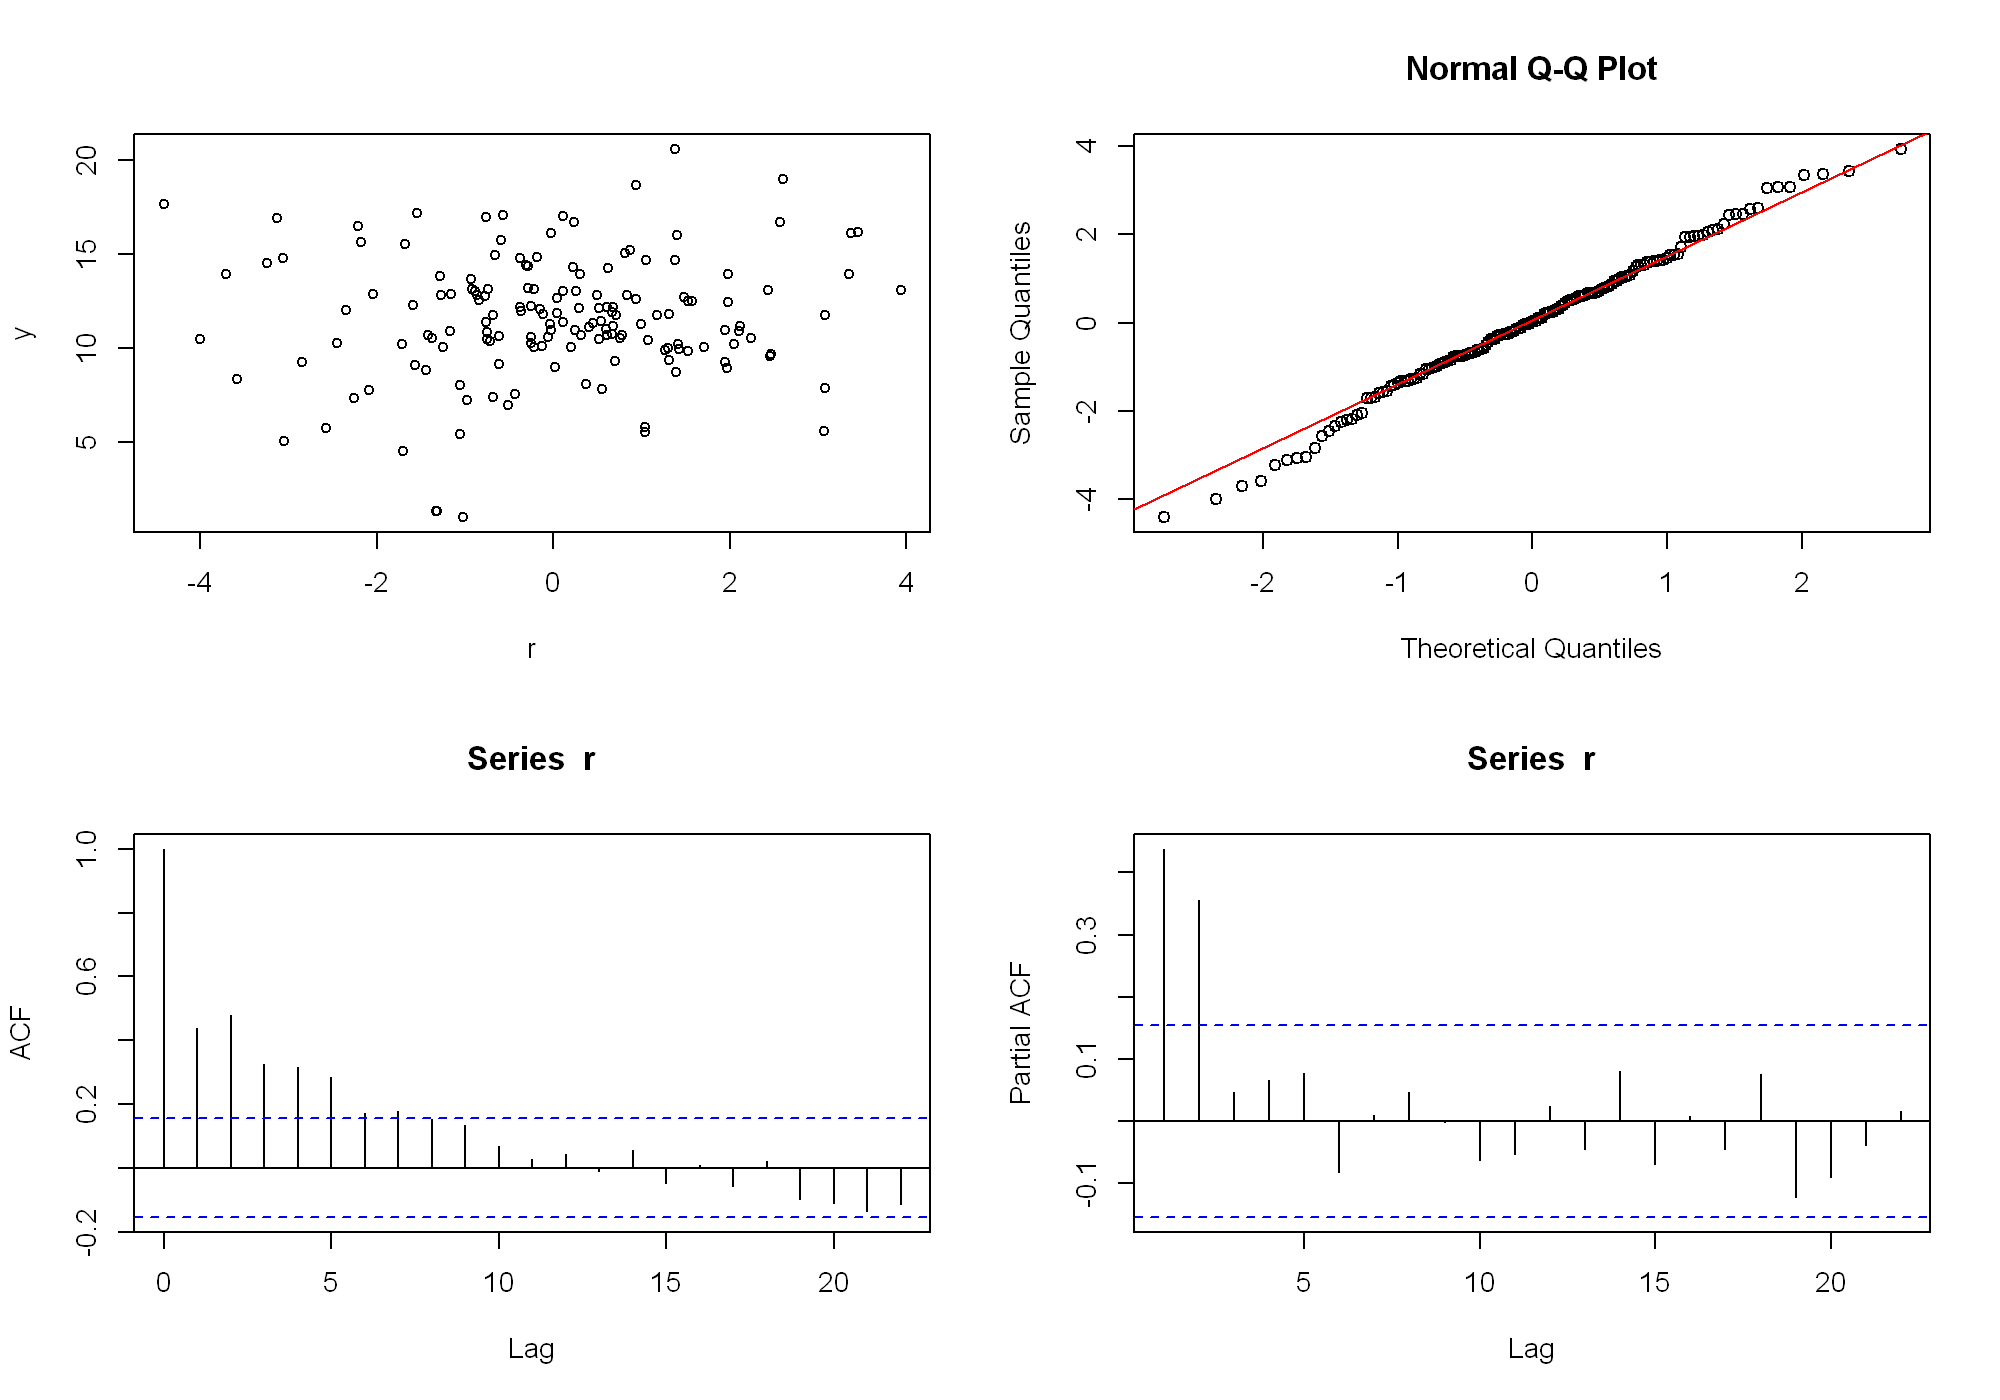

In [127]:
r <- na.omit(model3$residuals)
y <- as.numeric(model3$fitted)
par(mfrow = c(2,1))
plot(r,type="l")
plot(nursing,type="p")
lines(y,col="red")
par(mfrow = c(2,2))

plot(r,y,type="p")
qqnorm(r)
qqline(r,col="red")
acf(r)
pacf(r)


In [128]:
model3 <- gls(
  nursing ~   lockons + daynight,
  correlation = corARMA(p = 2, q = 0, form = ~ period),
  method = "ML"
)

In [129]:
model3

Generalized least squares fit by maximum likelihood
  Model: nursing ~ lockons + daynight 
  Data: NULL 
  Log-likelihood: -272.7481

Coefficients:
(Intercept)     lockons    daynight 
  1.8658371   2.6978195  -0.2894169 

Correlation Structure: ARMA(2,0)
 Formula: ~period 
 Parameter estimate(s):
     Phi1      Phi2 
0.2730737 0.3855714 
Degrees of freedom: 160 total; 157 residual
Residual standard error: 1.607282 

In [130]:
summary(model3)

Generalized least squares fit by maximum likelihood
  Model: nursing ~ lockons + daynight 
  Data: NULL 
       AIC      BIC    logLik
  557.4963 575.9473 -272.7481

Correlation Structure: ARMA(2,0)
 Formula: ~period 
 Parameter estimate(s):
     Phi1      Phi2 
0.2730737 0.3855714 

Coefficients:
                 Value Std.Error   t-value p-value
(Intercept)  1.8658371 0.5069452  3.680550  0.0003
lockons      2.6978195 0.1141677 23.630315  0.0000
daynight    -0.2894169 0.1509257 -1.917611  0.0570

 Correlation: 
         (Intr) lockns
lockons  -0.785       
daynight -0.089 -0.074

Standardized residuals:
         Min           Q1          Med           Q3          Max 
-2.960189589 -0.610025367  0.007837007  0.672342679  2.513656398 

Residual standard error: 1.607282 
Degrees of freedom: 160 total; 157 residual

In [131]:
t.url <- "http://stat.ethz.ch/Teaching/Datasets/WBL/varve.dat"
d.varve <- ts(scan(t.url)[201:550])

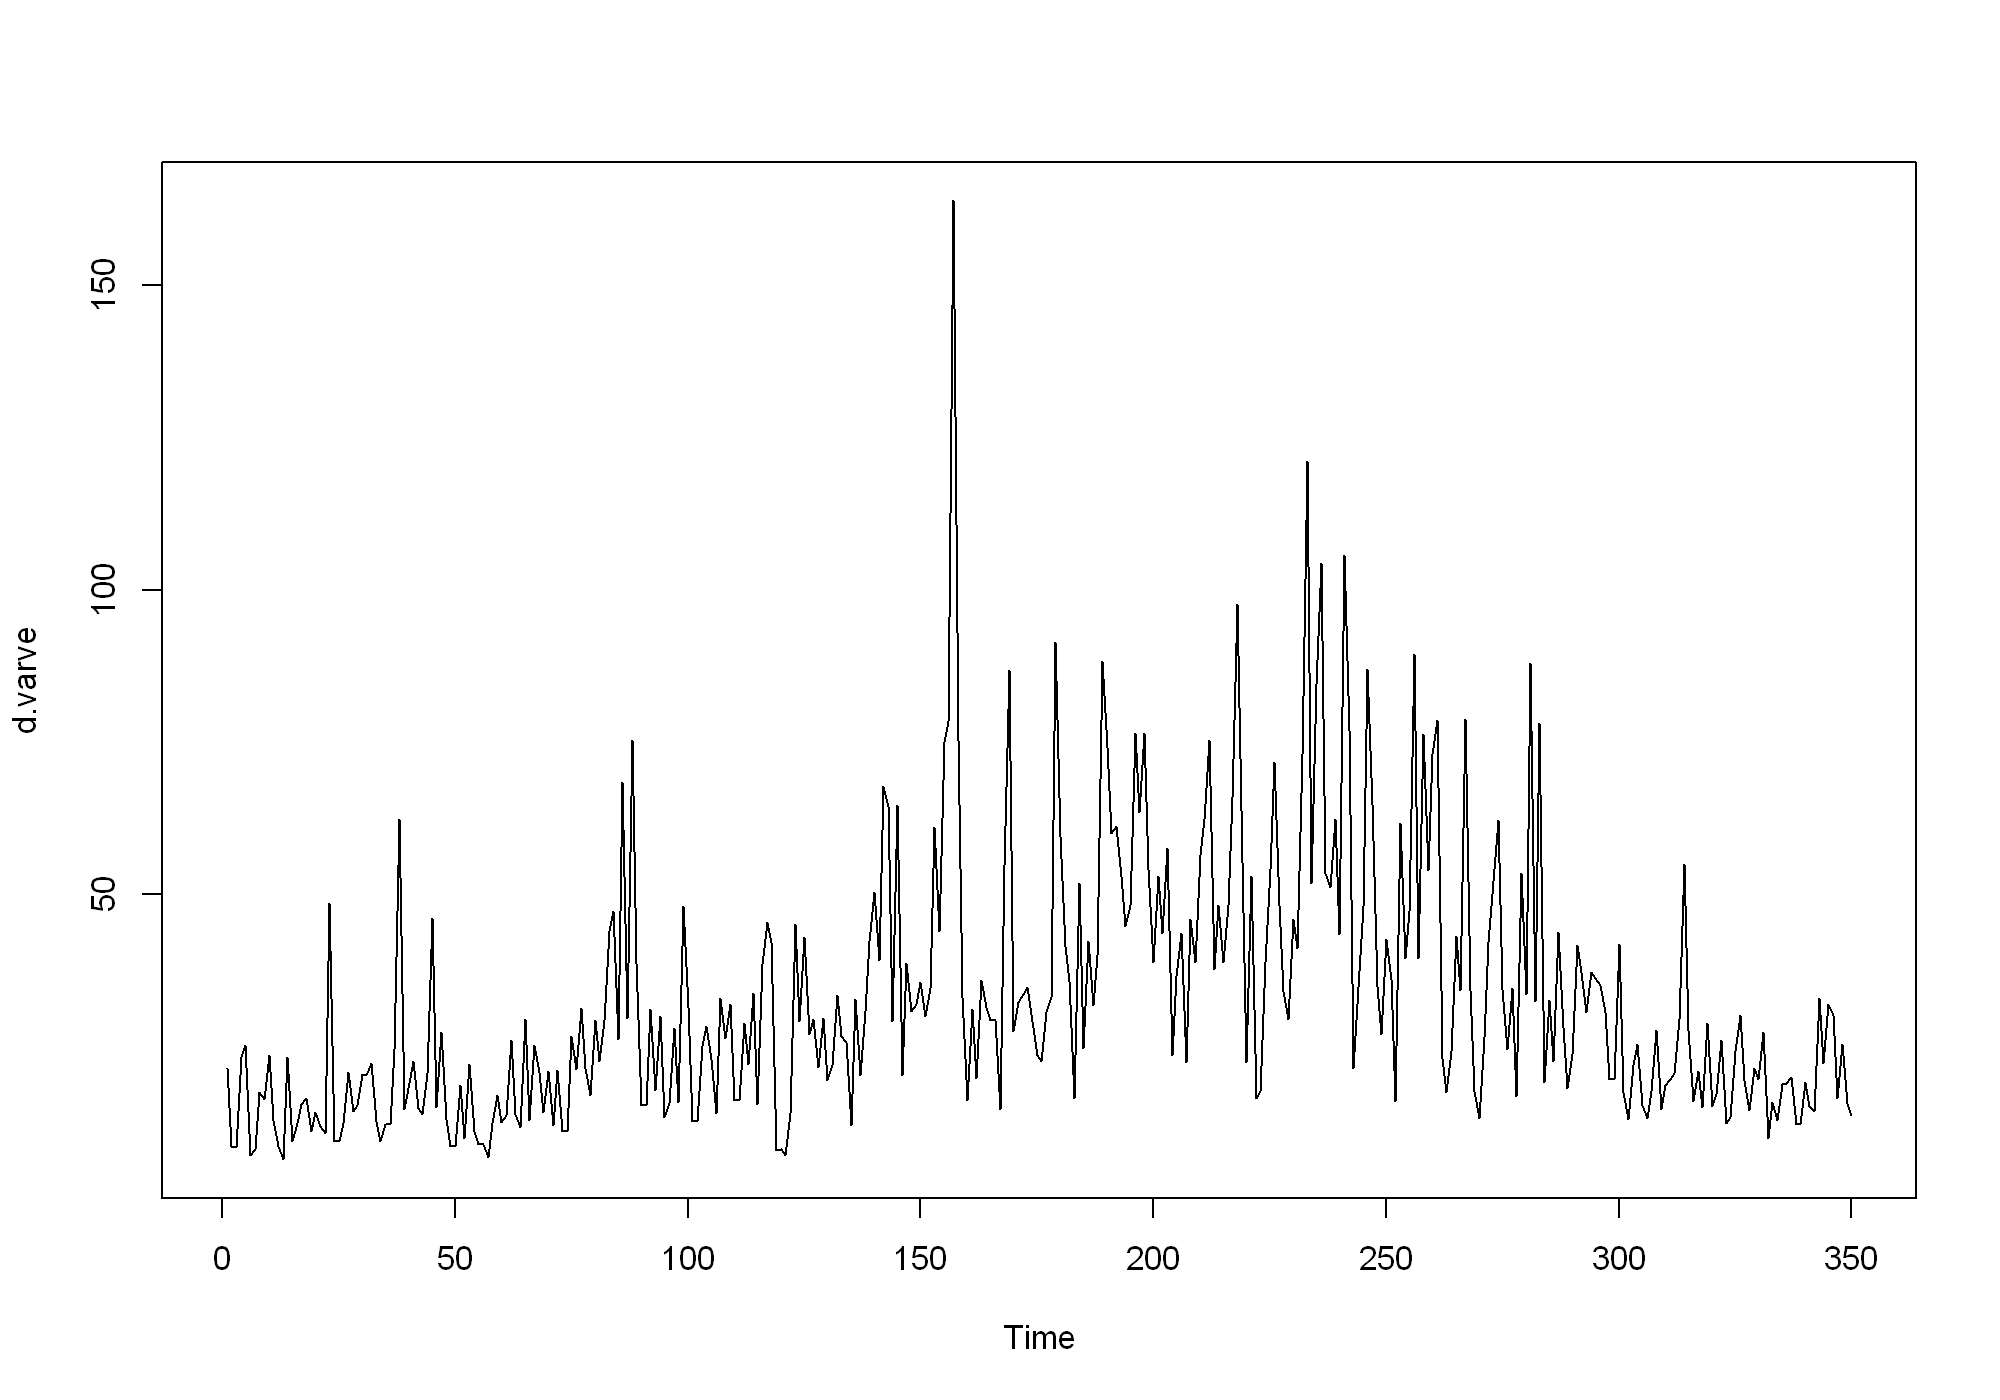

In [132]:
plot(d.varve)

In [133]:
d.varve_log <- log(d.varve)

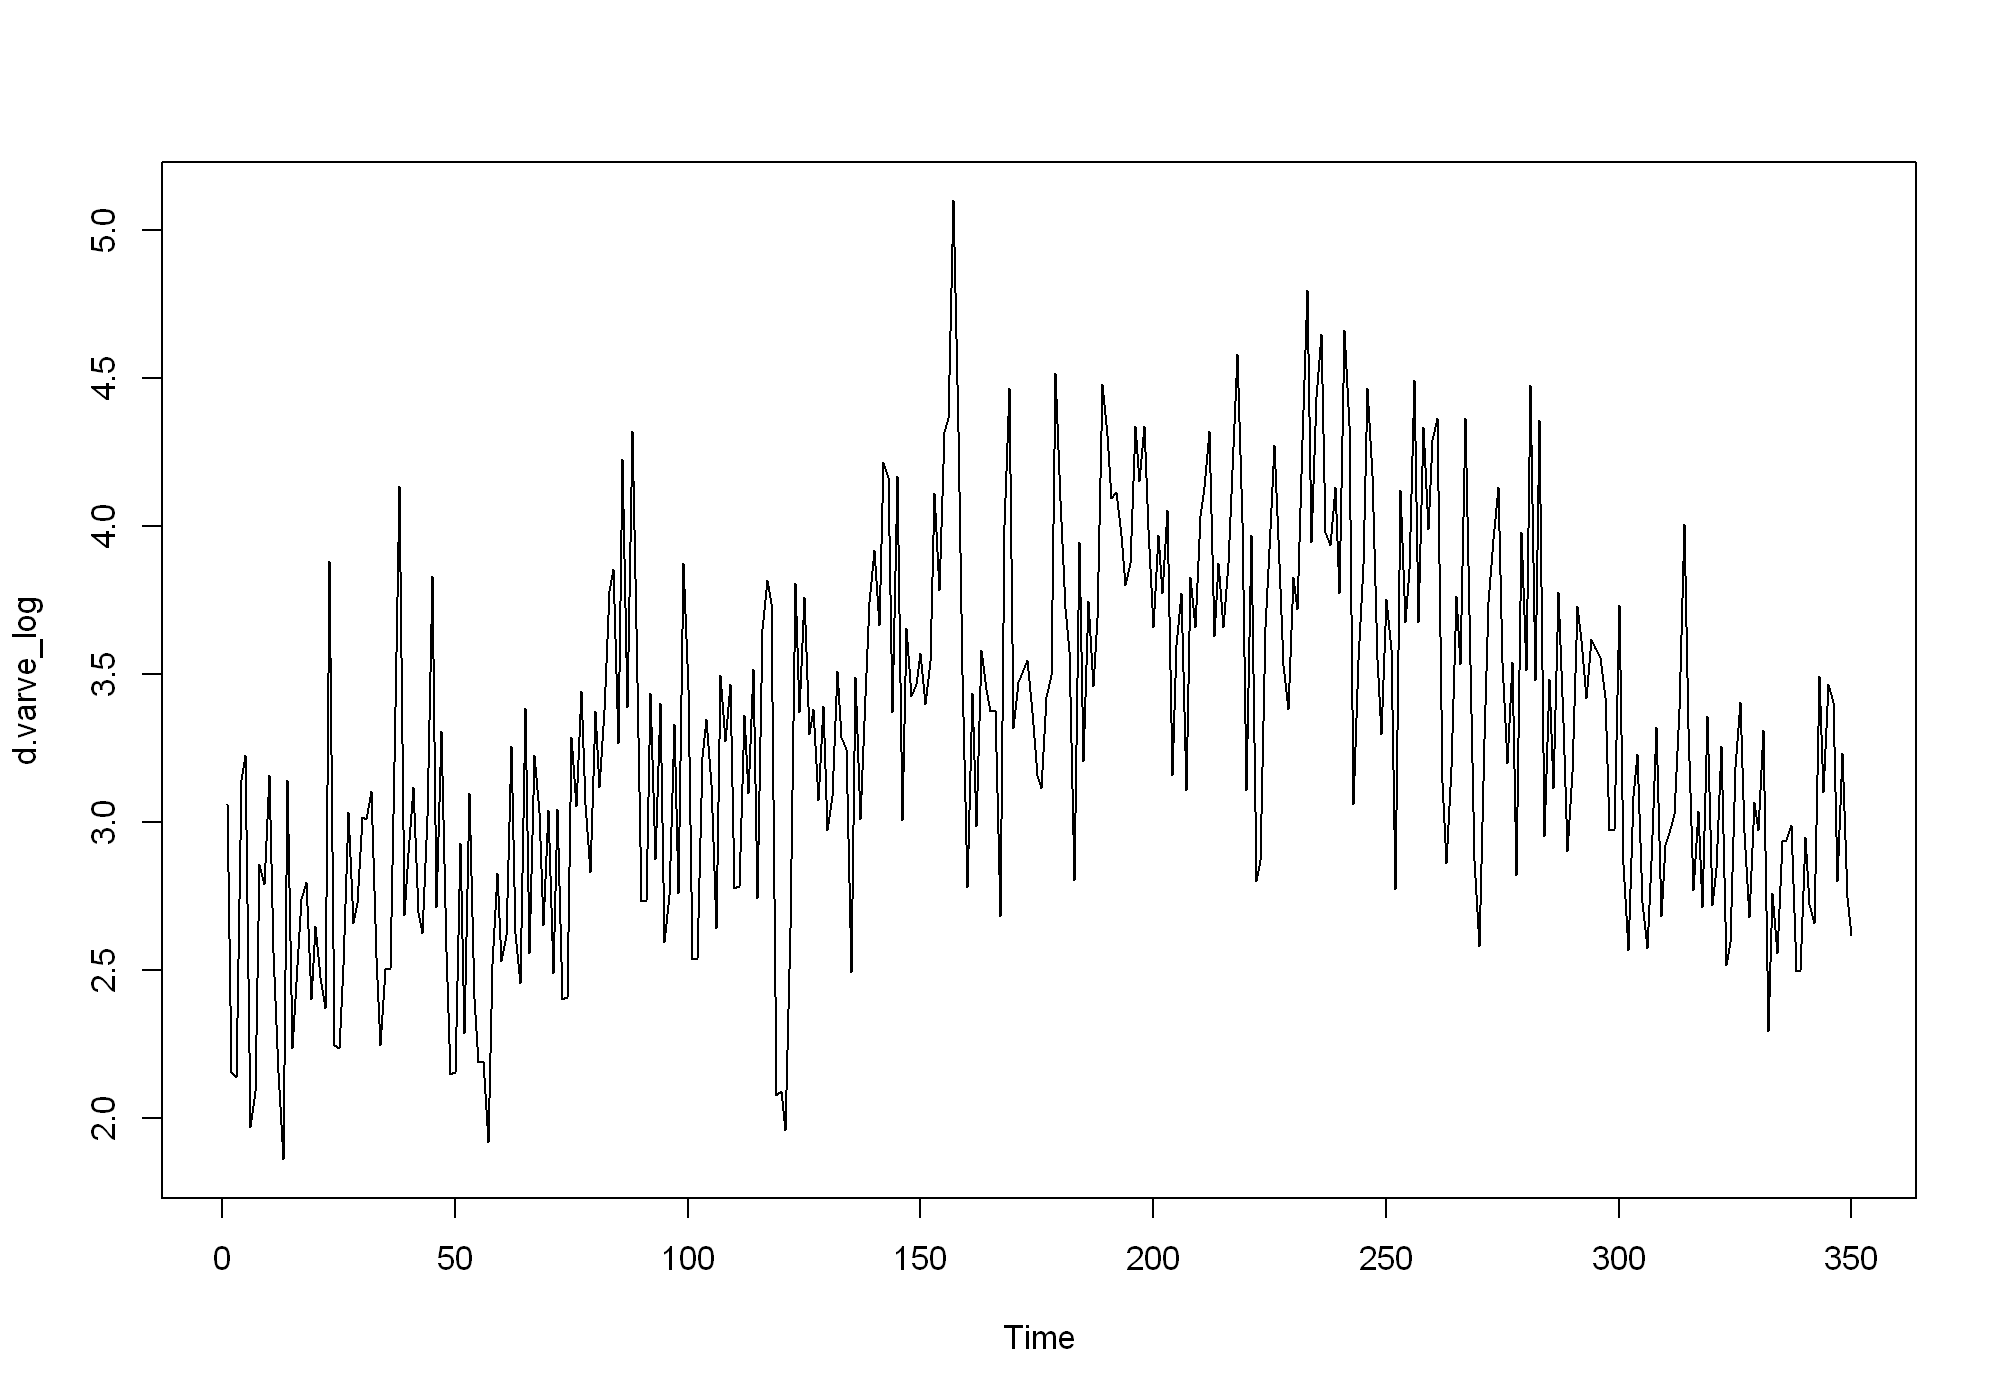

In [134]:
plot(d.varve_log)

In [135]:
d.varve_log_diff <- diff(d.varve_log)

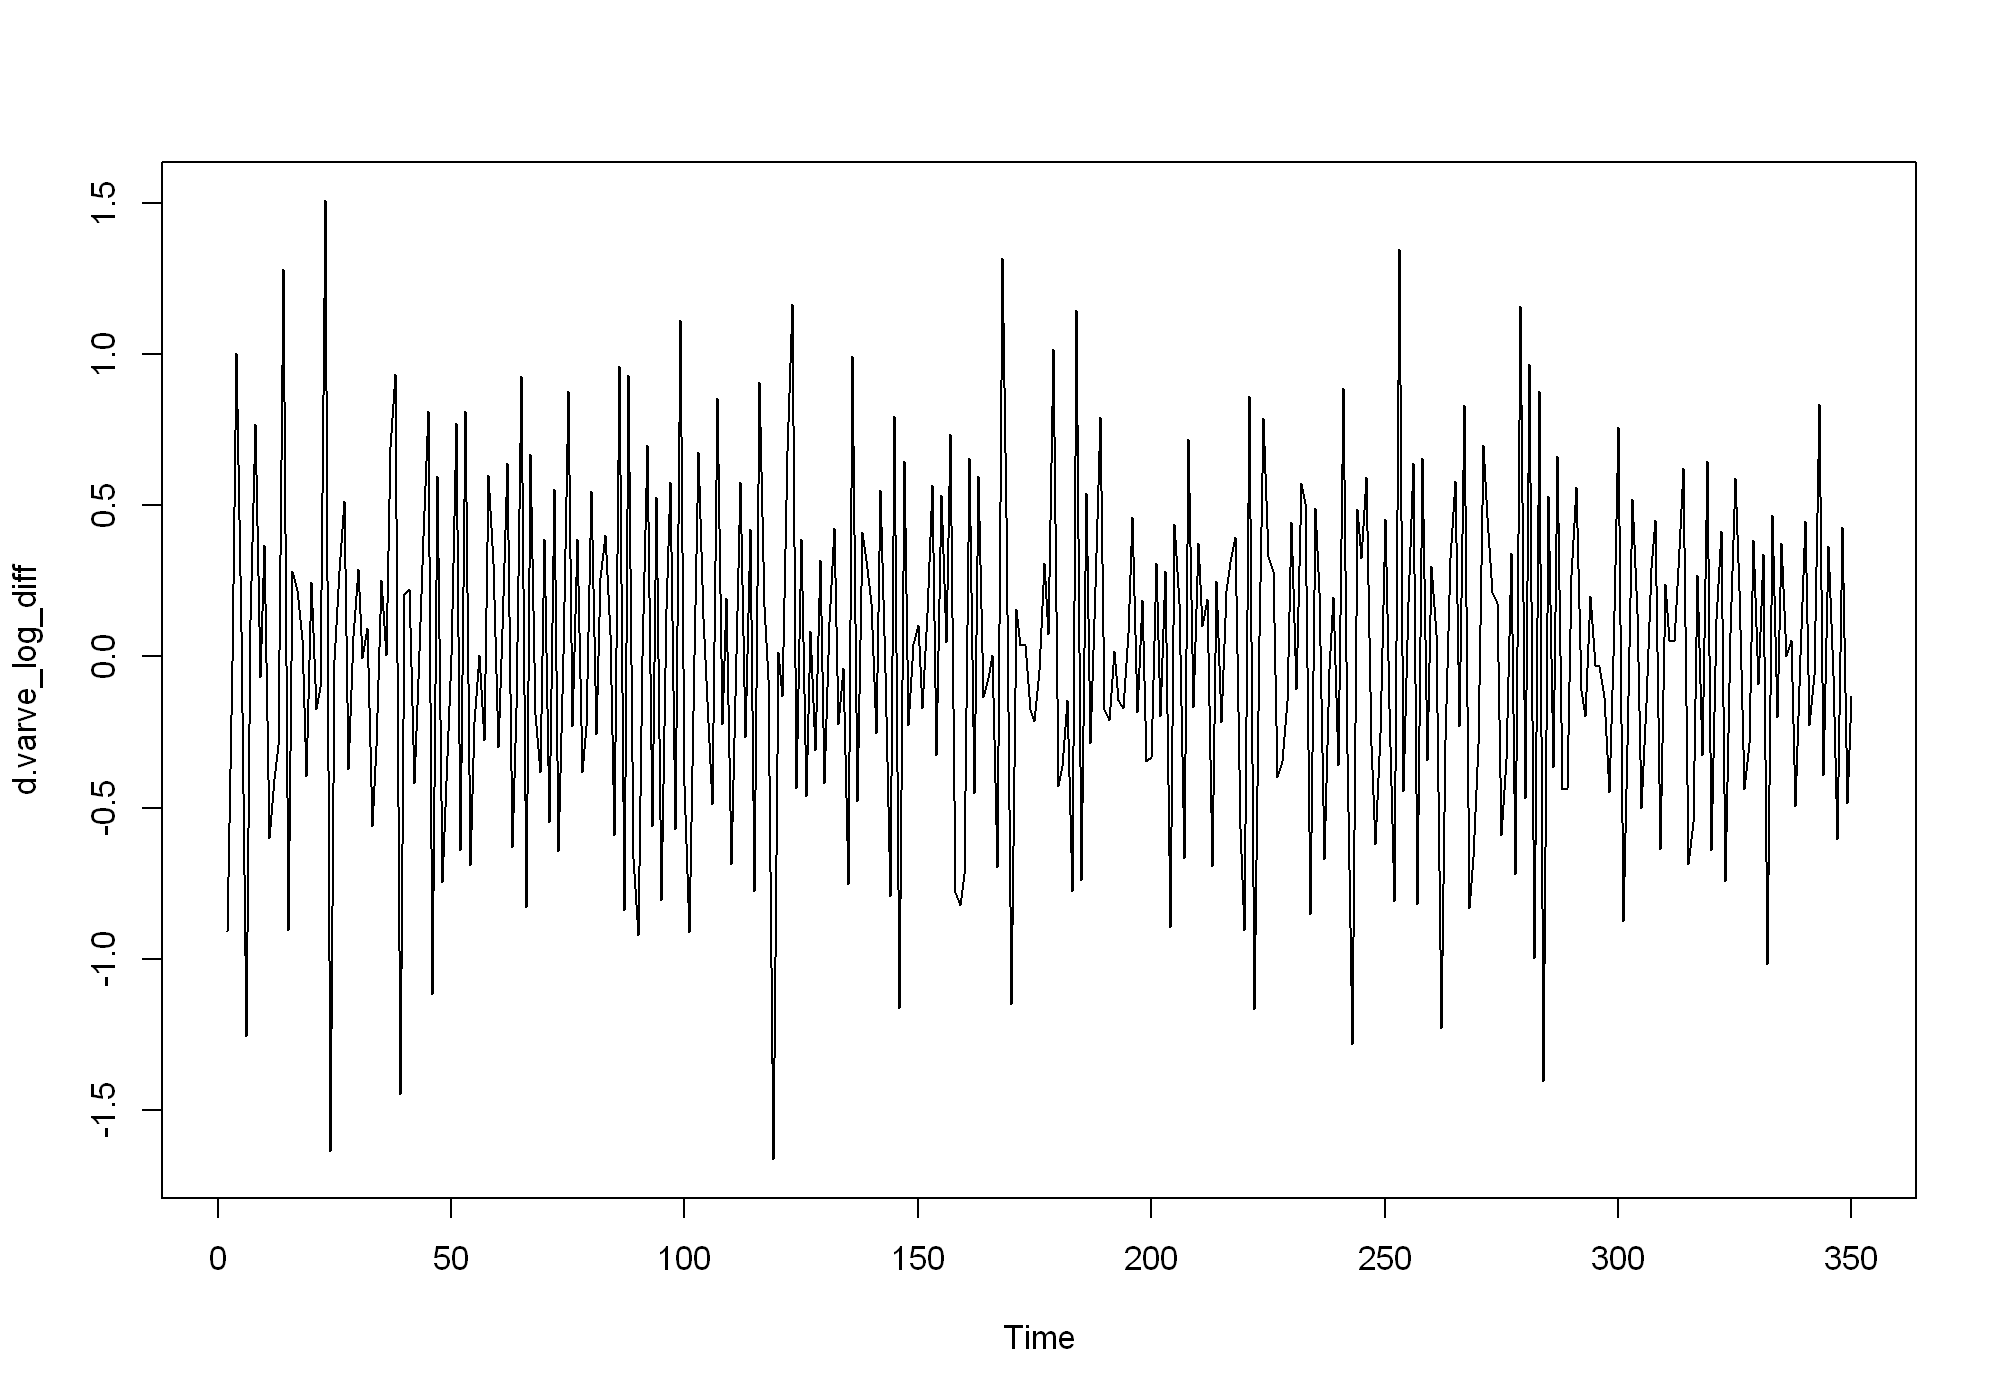

In [136]:
plot(d.varve_log_diff)

In [138]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)

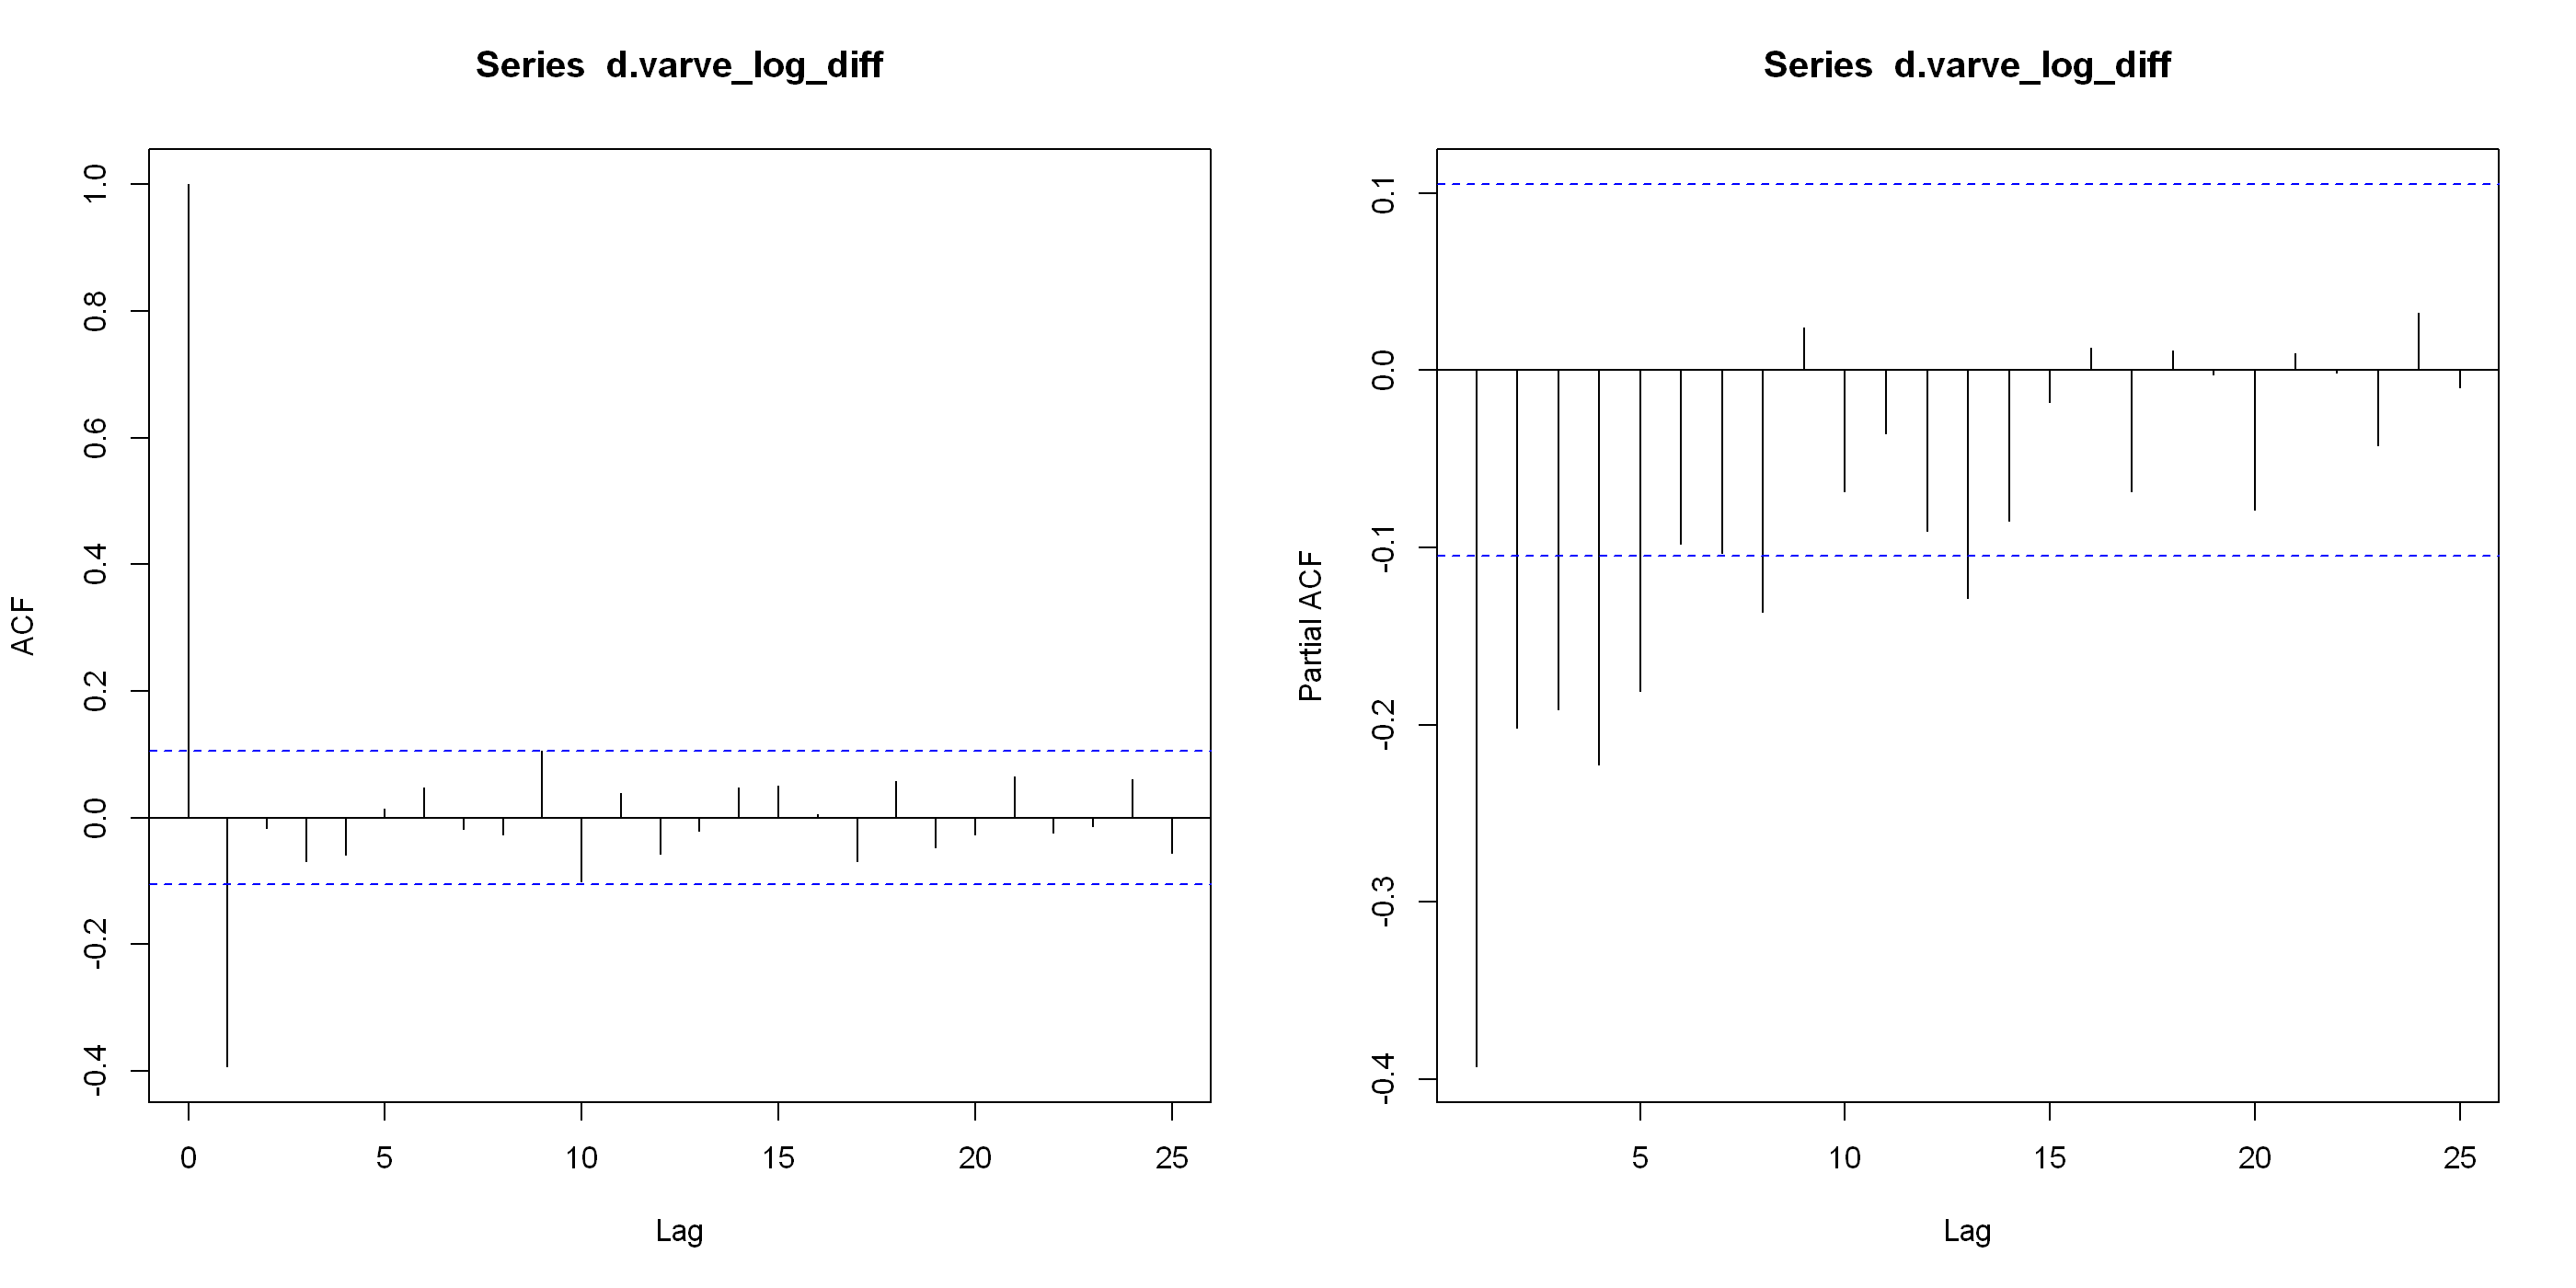

In [139]:
par(mfrow=c(1,2))
acf(d.varve_log_diff)
pacf(d.varve_log_diff)


In [140]:
library(forecast)

In [151]:
fit <- arima(d.varve_log_diff,order = c(3,0,3))

In [152]:
fit


Call:
arima(x = d.varve_log_diff, order = c(3, 0, 3))

Coefficients:
          ar1      ar2     ar3      ma1     ma2      ma3  intercept
      -0.6169  -0.6891  0.2821  -0.0500  0.1739  -0.8958     0.0009
s.e.   0.0607   0.0693  0.0604   0.0296  0.0427   0.0388     0.0028

sigma^2 estimated as 0.2074:  log likelihood = -221.92,  aic = 459.85

In [ ]:
auto.arima(d.varve_log_diff,stepwise = TRUE,trace = TRUE)


 Fitting models using approximations to speed things up...

 ARIMA(2,0,2) with non-zero mean : 464.3083
 ARIMA(0,0,0) with non-zero mean : 591.7136
 ARIMA(1,0,0) with non-zero mean : 533.1391
 ARIMA(0,0,1) with non-zero mean : 477.3716
 ARIMA(0,0,0) with zero mean     : 589.6922
 ARIMA(1,0,2) with non-zero mean : 466.3287
 ARIMA(2,0,1) with non-zero mean : 465.0292
 ARIMA(3,0,2) with non-zero mean : 467.1089
 ARIMA(2,0,3) with non-zero mean : 458.0258
 ARIMA(1,0,3) with non-zero mean : 462.8944
 ARIMA(3,0,3) with non-zero mean : 456.4341
 ARIMA(4,0,3) with non-zero mean : 448.5331
 ARIMA(4,0,2) with non-zero mean : 466.0485
 ARIMA(5,0,3) with non-zero mean : 451.1407
 ARIMA(4,0,4) with non-zero mean : 459.1222
 ARIMA(3,0,4) with non-zero mean : Inf
 ARIMA(5,0,2) with non-zero mean : 465.8341
 ARIMA(5,0,4) with non-zero mean : 450.8175
 ARIMA(4,0,3) with zero mean     : 446.4443
 ARIMA(3,0,3) with zero mean     : 454.4899
 ARIMA(4,0,2) with zero mean     : 464.0733
 ARIMA(5,0,3) with z

Series: d.varve_log_diff 
ARIMA(4,0,3) with zero mean 

Coefficients:
          ar1      ar2     ar3      ar4      ma1     ma2      ma3
      -0.5404  -0.7061  0.2386  -0.0205  -0.1251  0.2387  -0.8808
s.e.   0.0648   0.0801  0.0744   0.0624   0.0363  0.0520   0.0429

sigma^2 = 0.2123:  log likelihood = -222.26
AIC=460.53   AICc=460.95   BIC=491.37

In [153]:
model <- arima(d.varve_log_diff,order = c(3,0,3))

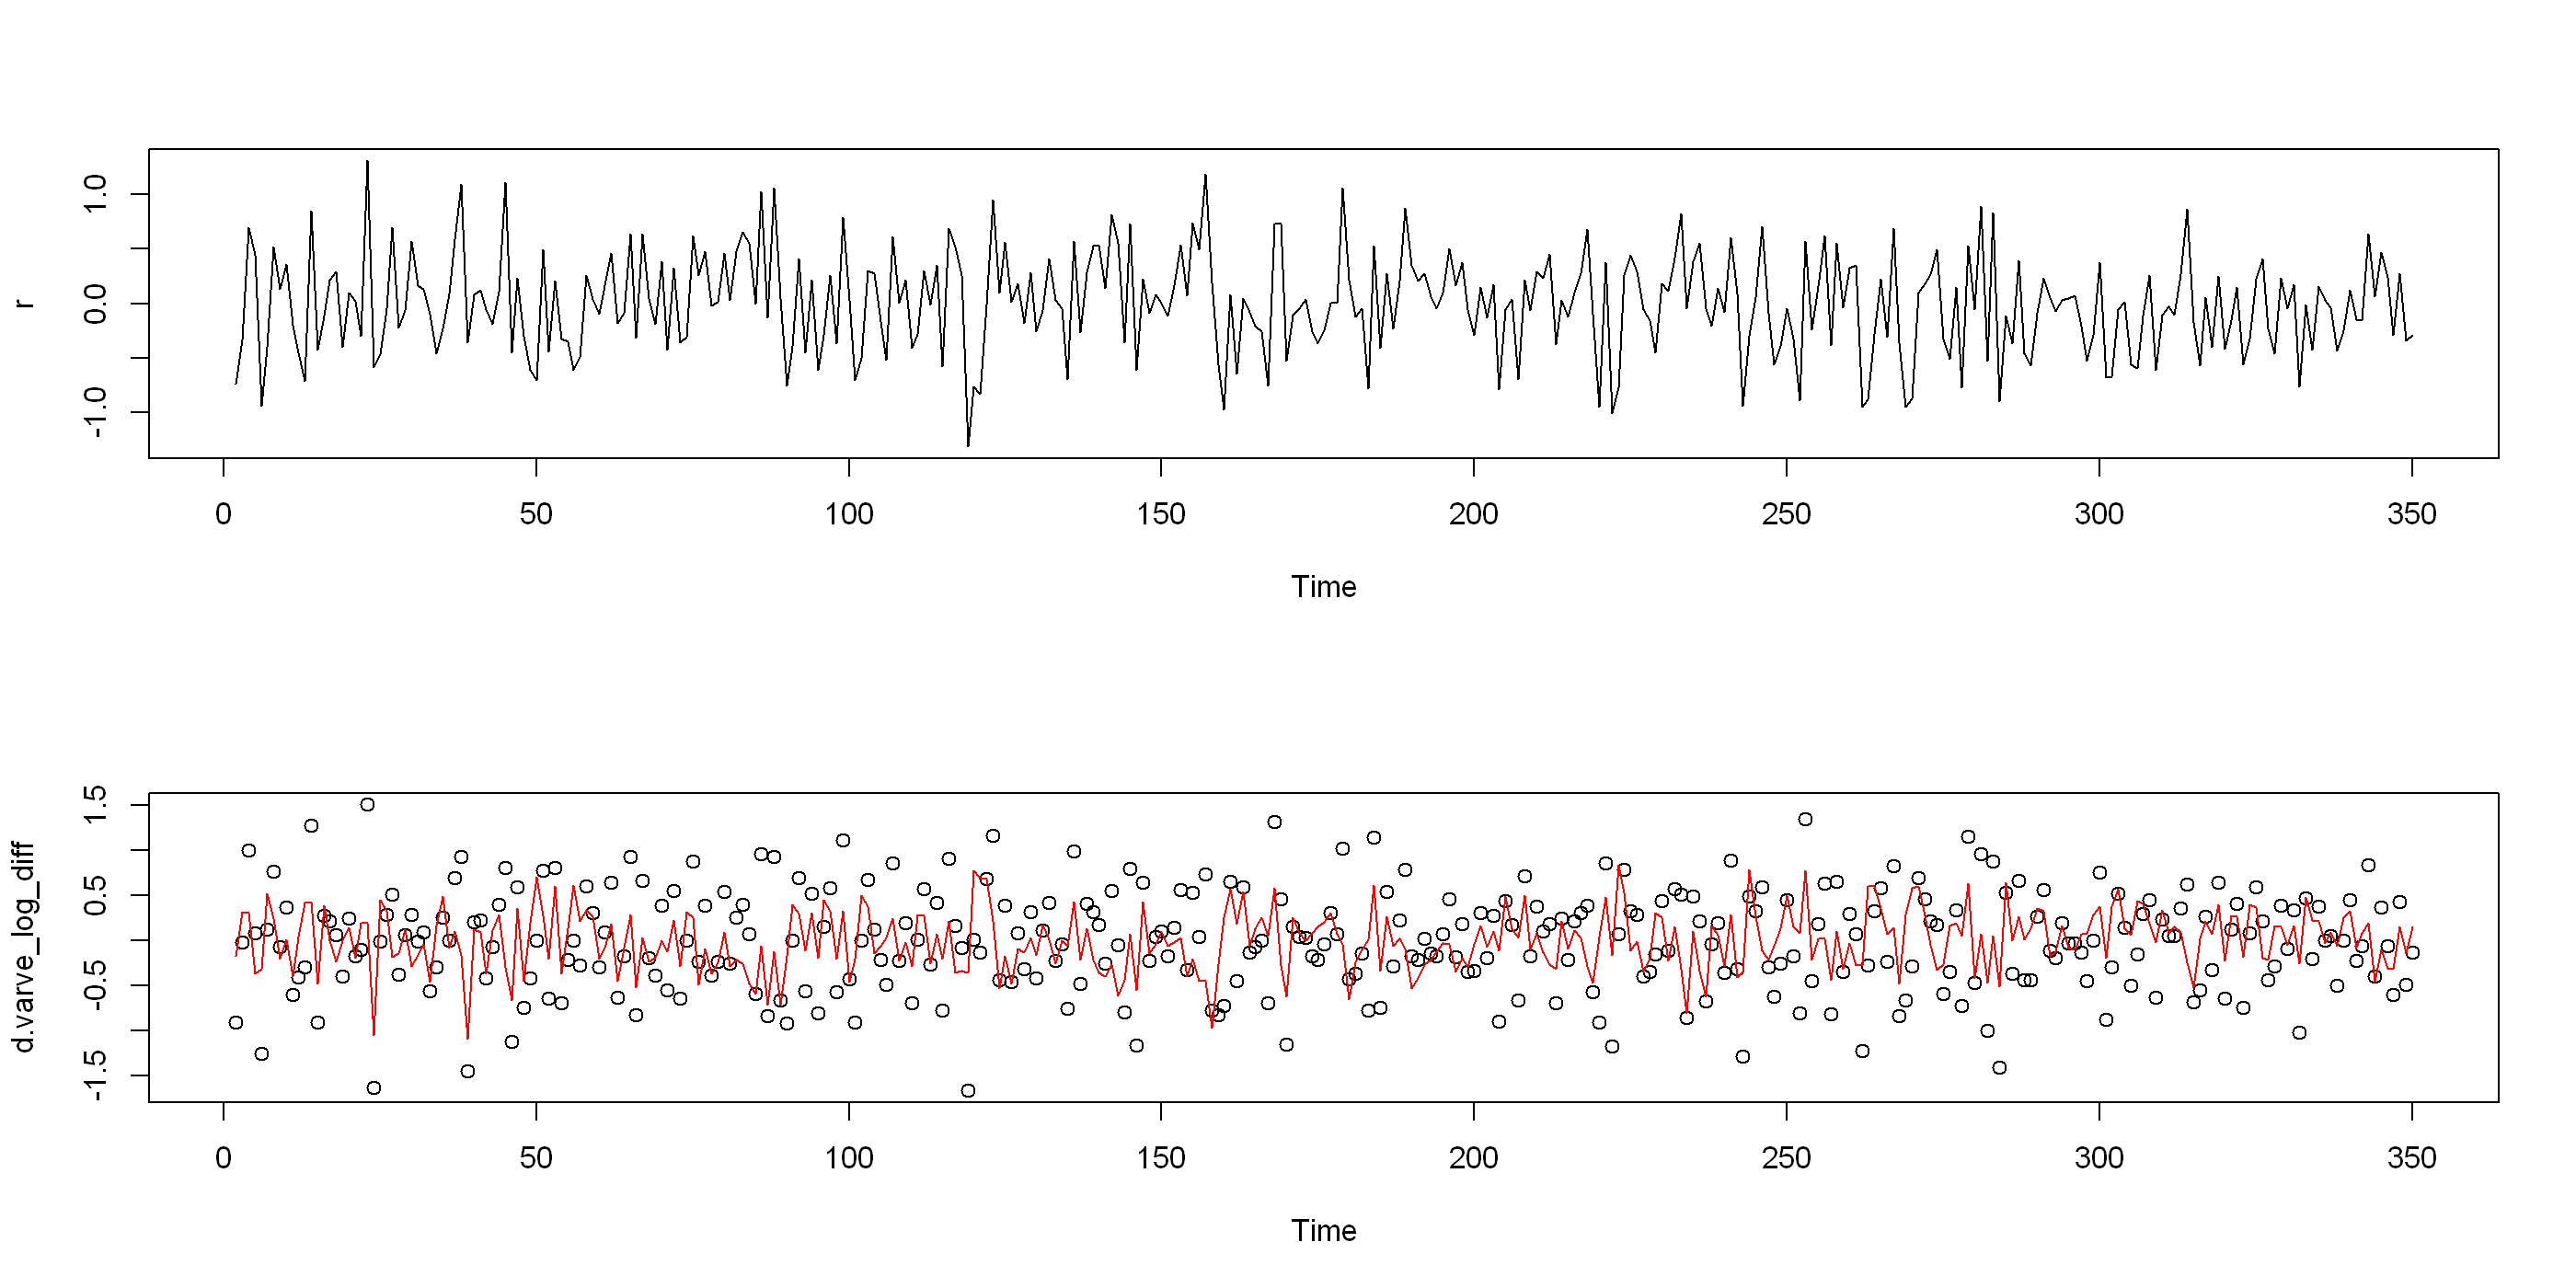

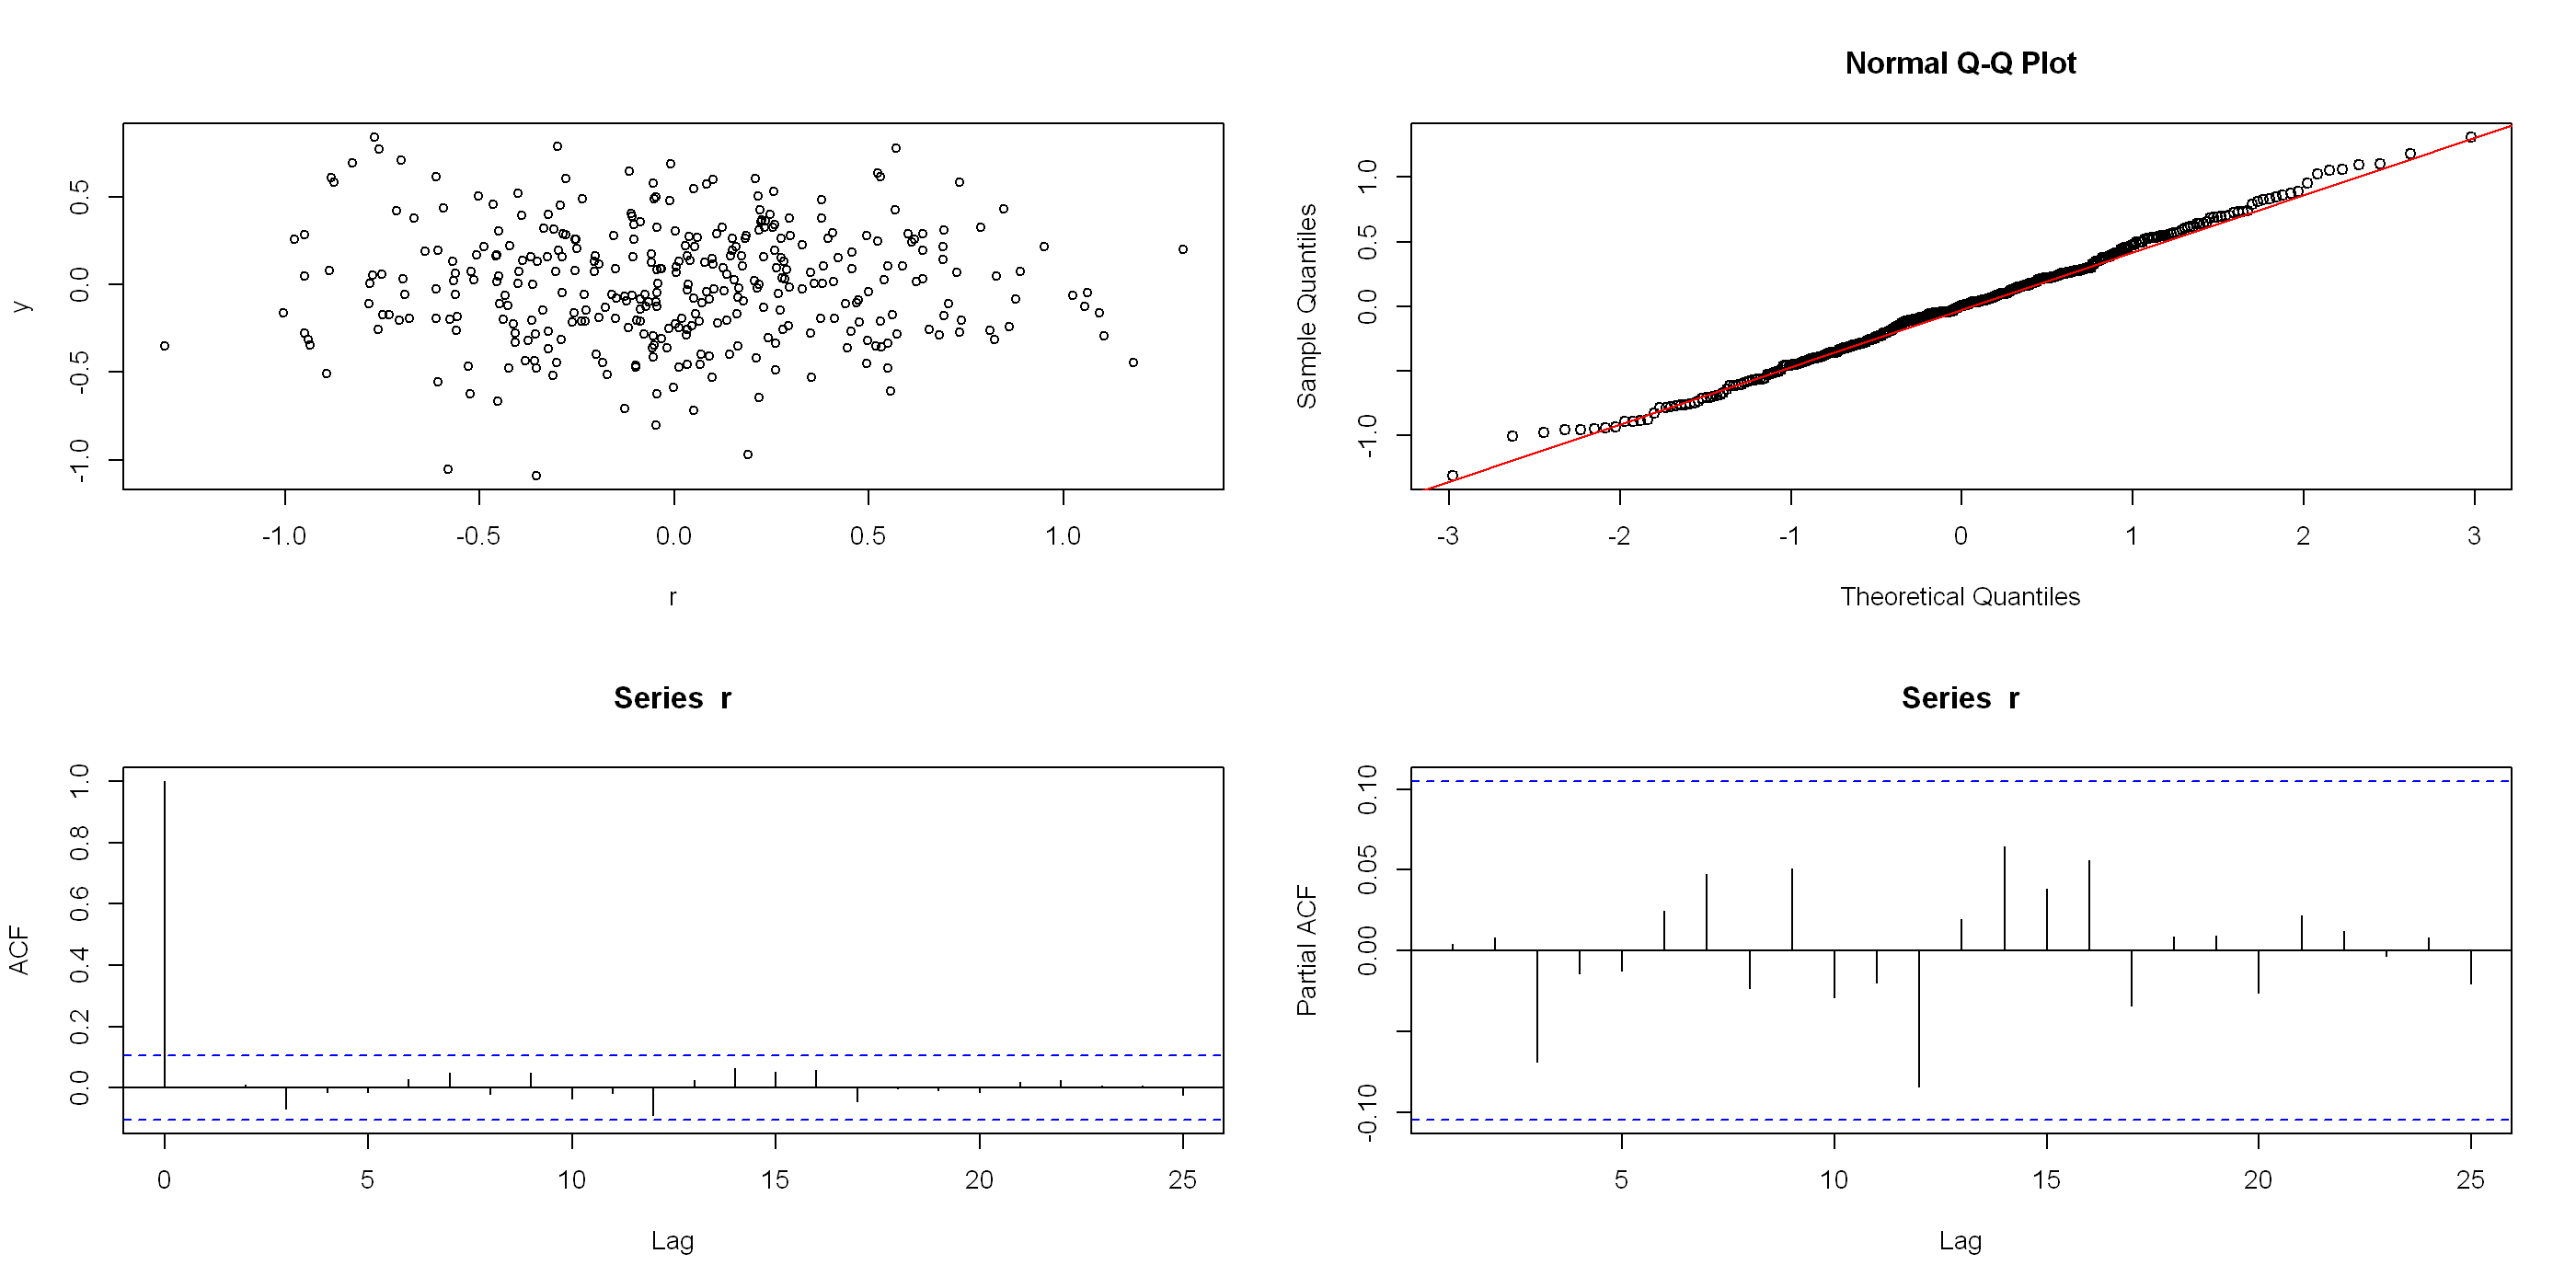

In [154]:
r <- na.omit(model$residuals)
y <- d.varve_log_diff-r
par(mfrow = c(2,1))
plot(r,type="l")
plot(d.varve_log_diff,type="p")
lines(y,col="red")
par(mfrow = c(2,2))

plot(r,y,type="p")
qqnorm(r)
qqline(r,col="red")
acf(r)
pacf(r)


In [157]:
auto.arima(d.varve_log,trace = TRUE,stepwise = TRUE)


 Fitting models using approximations to speed things up...

 ARIMA(2,1,2) with drift         : 465.4623
 ARIMA(0,1,0) with drift         : 592.8676
 ARIMA(1,1,0) with drift         : 534.2931
 ARIMA(0,1,1) with drift         : 478.5256
 ARIMA(0,1,0)                    : 590.8462
 ARIMA(1,1,2) with drift         : 467.4827
 ARIMA(2,1,1) with drift         : 466.1831
 ARIMA(3,1,2) with drift         : 468.2629
 ARIMA(2,1,3) with drift         : 459.1798
 ARIMA(1,1,3) with drift         : 464.0484
 ARIMA(3,1,3) with drift         : 457.5881
 ARIMA(4,1,3) with drift         : 449.6871
 ARIMA(4,1,2) with drift         : 467.2025
 ARIMA(5,1,3) with drift         : 452.2947
 ARIMA(4,1,4) with drift         : 460.2761
 ARIMA(3,1,4) with drift         : Inf
 ARIMA(5,1,2) with drift         : 466.9881
 ARIMA(5,1,4) with drift         : 451.9715
 ARIMA(4,1,3)                    : 447.5983
 ARIMA(3,1,3)                    : 455.6439
 ARIMA(4,1,2)                    : 465.2273
 ARIMA(5,1,3)       

Series: d.varve_log 
ARIMA(4,1,3) 

Coefficients:
          ar1      ar2     ar3      ar4      ma1     ma2      ma3
      -0.5404  -0.7061  0.2386  -0.0205  -0.1251  0.2387  -0.8808
s.e.   0.0648   0.0801  0.0744   0.0624   0.0363  0.0520   0.0429

sigma^2 = 0.2123:  log likelihood = -222.26
AIC=460.53   AICc=460.95   BIC=491.37

In [ ]:
fit <- arima(d.varve_log,order = c(1,1,1))


Call:
arima(x = d.varve_log, order = c(1, 1, 1))

Coefficients:
         ar1      ma1
      0.2461  -0.9140
s.e.  0.0590   0.0234

sigma^2 estimated as 0.2138:  log likelihood = -226.65,  aic = 459.3

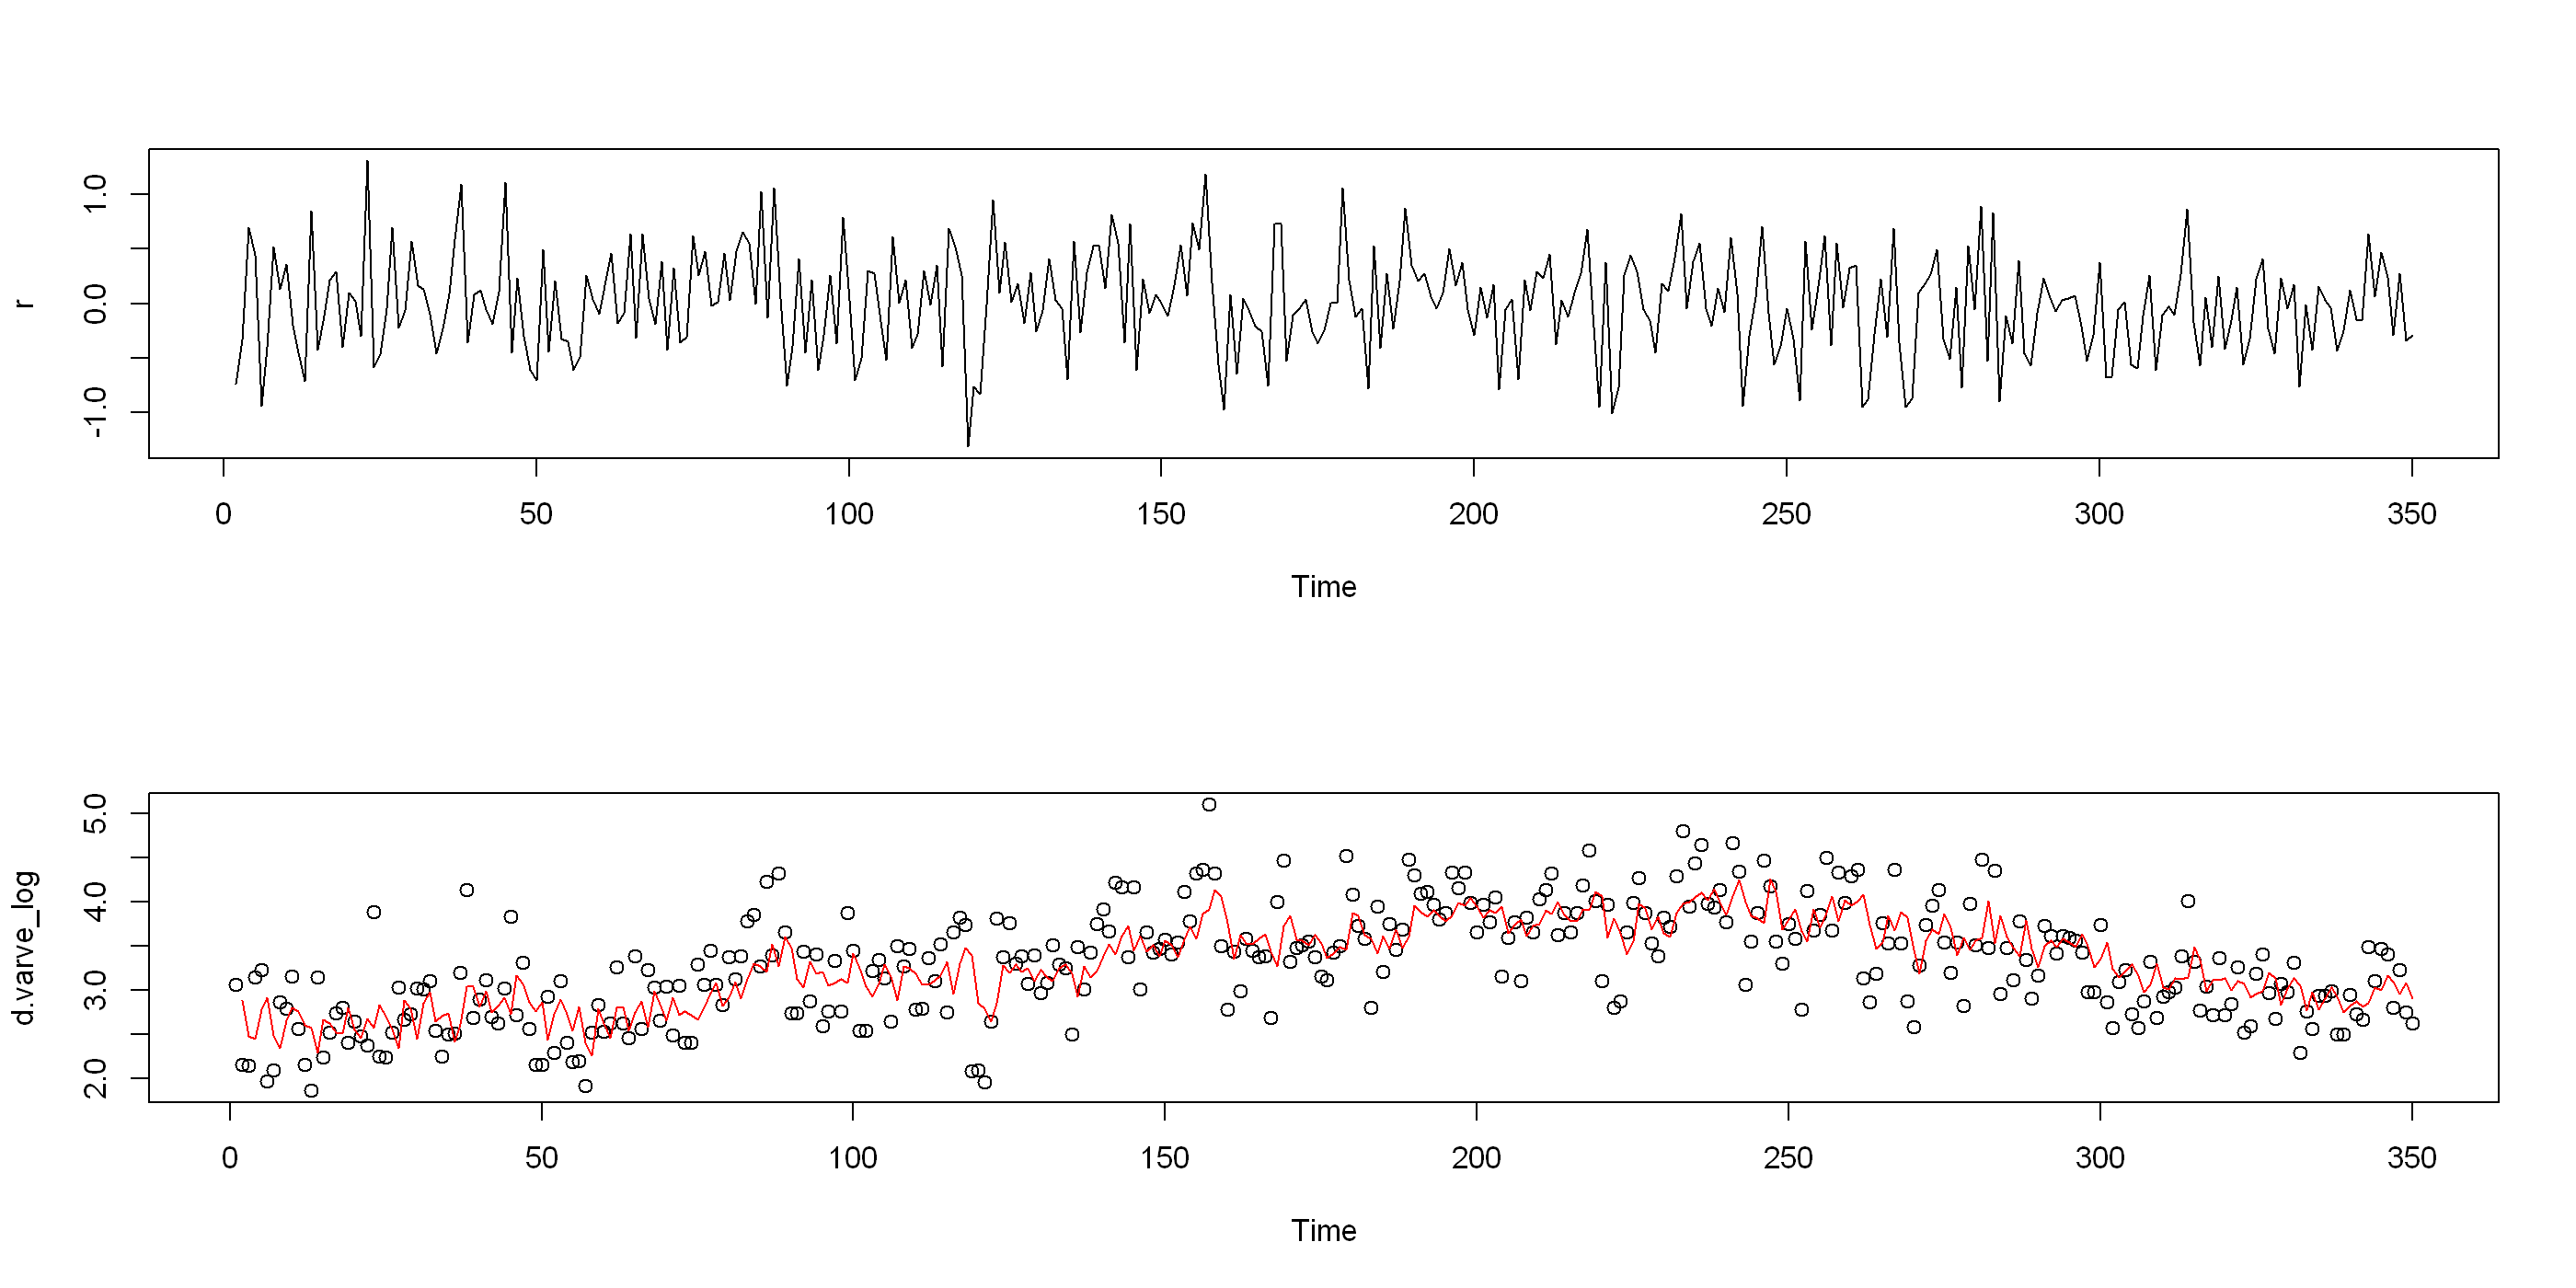

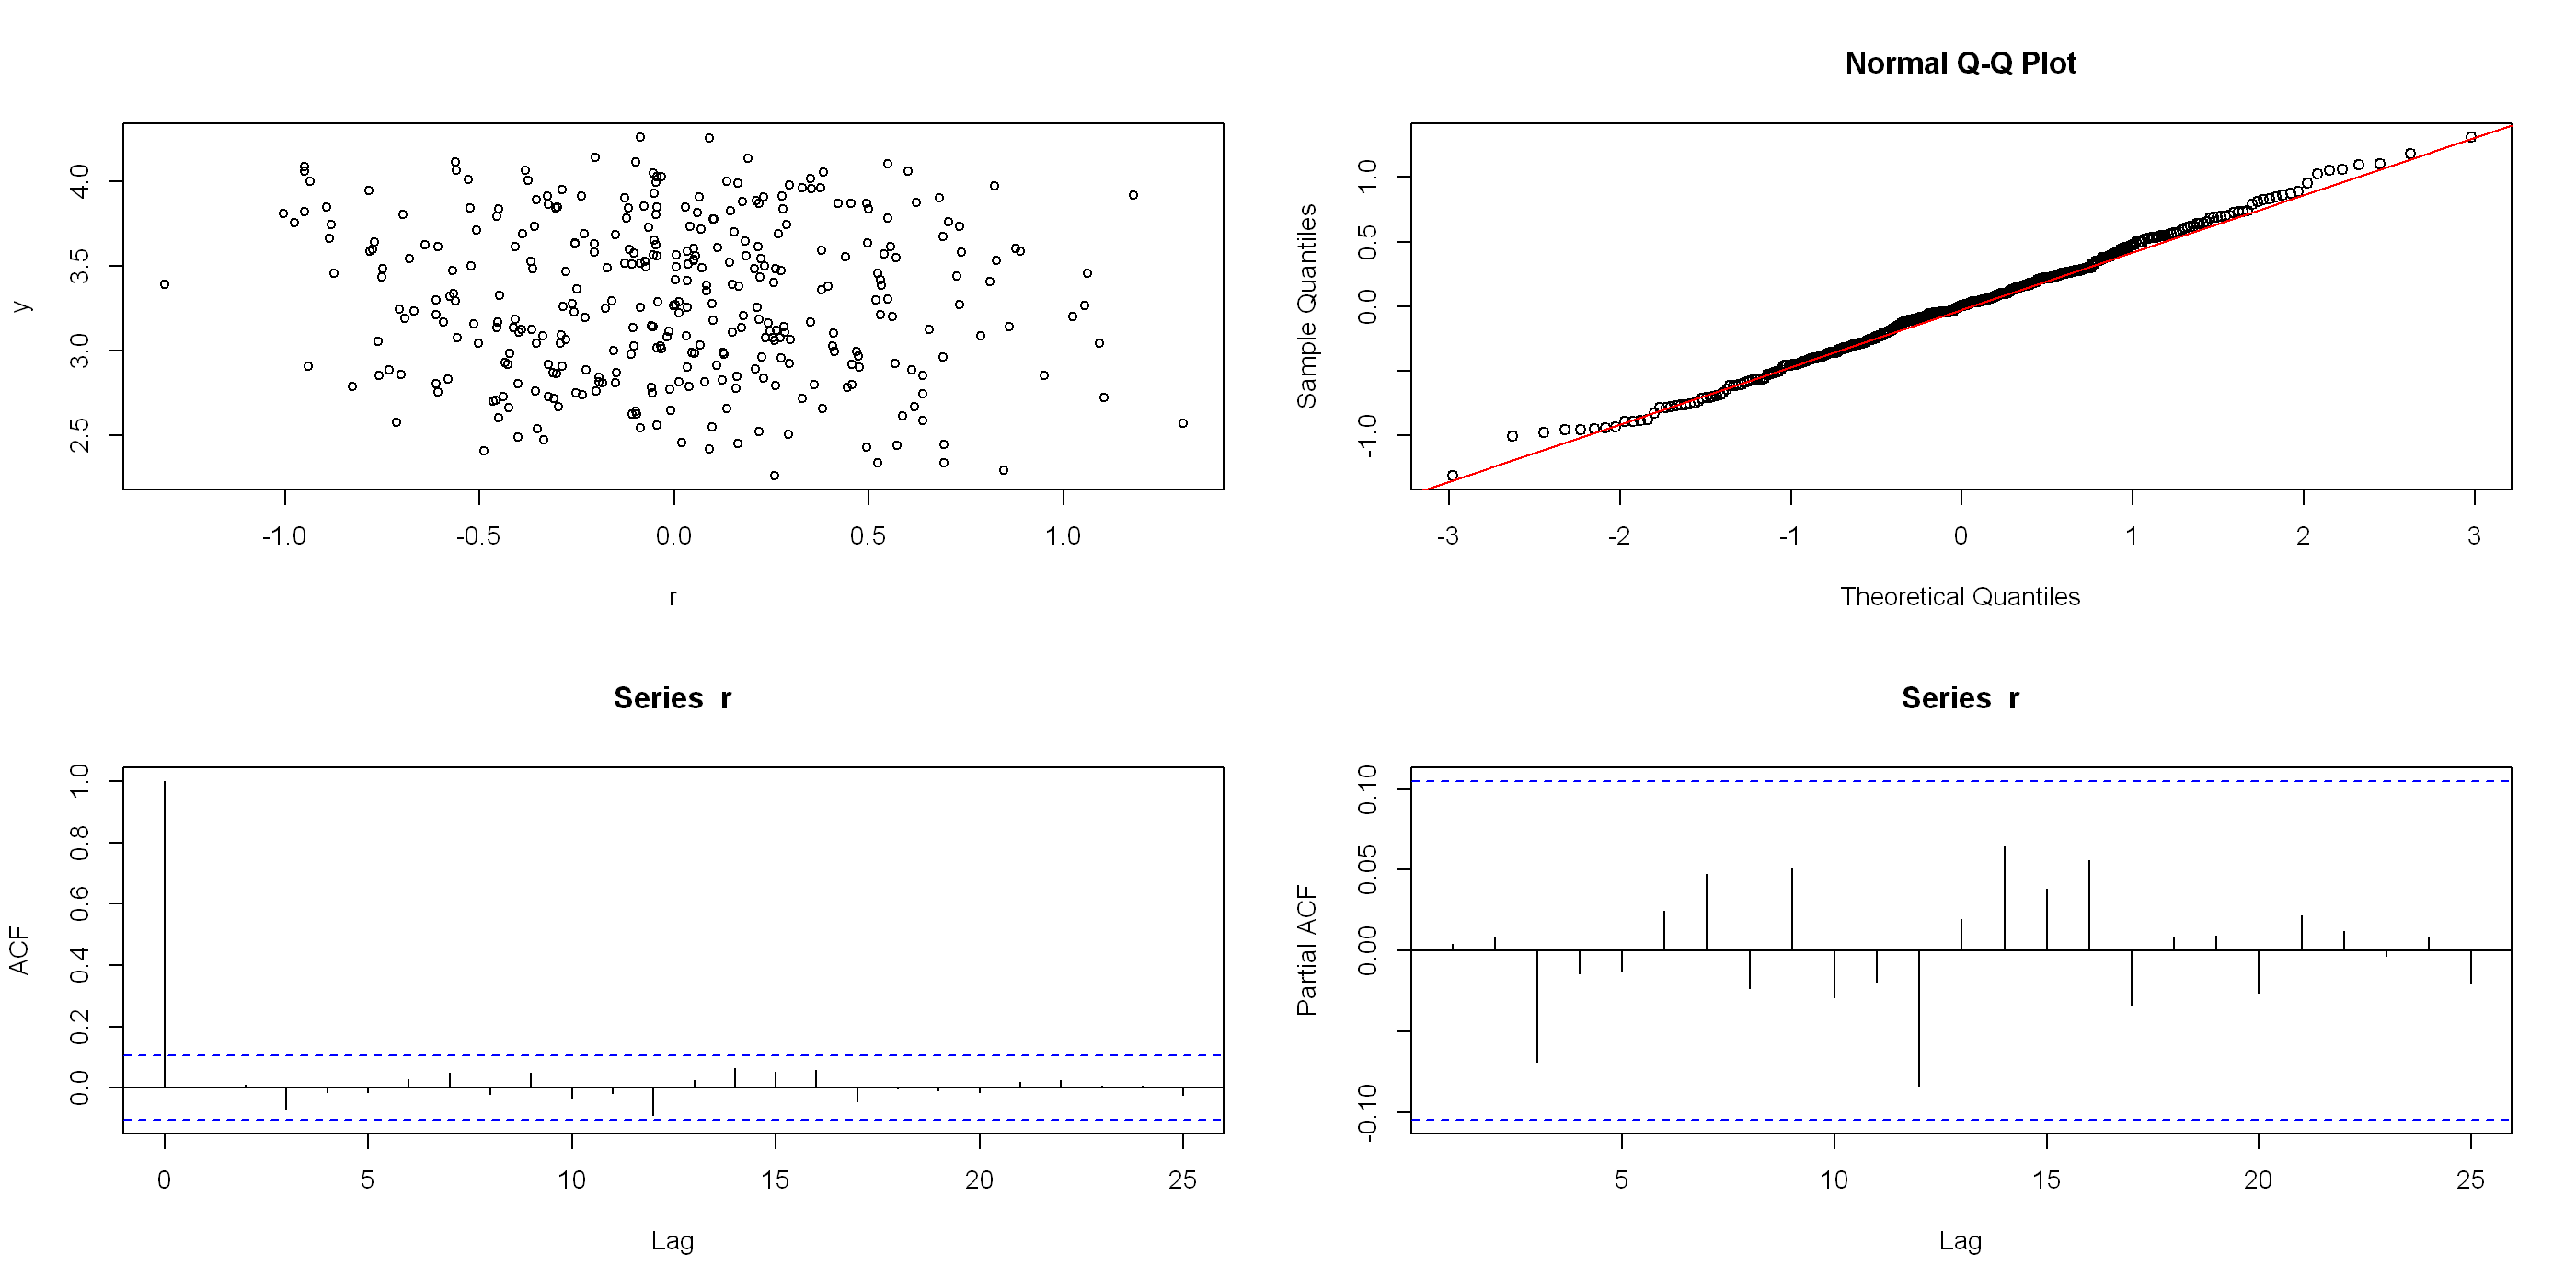

In [159]:
r <- na.omit(fit$residuals)
y <- d.varve_log-r
par(mfrow = c(2,1))
plot(r,type="l")
plot(d.varve_log,type="p")
lines(y,col="red")
par(mfrow = c(2,2))

plot(r,y,type="p")
qqnorm(r)
qqline(r,col="red")
acf(r)
pacf(r)
